# Modelos Predictivos - Precio de Casas

Este cuaderno implementa un flujo de modelado reutilizable para `SalePrice`, definiendo desde el inicio la estrategia de transformacion de categoricas para evitar duplicacion entre modelos.

## Pregunta de investigacion

¿Es posible reducir al menos en un 50% el RMSE de la prediccion del precio de viviendas usando modelos avanzados frente a un baseline que predice la media?

## Hoja de ruta
1. Importar librerias y carga previa
2. Modelos predictivos
3. Modelo final

## 1. Importar librerias y carga previa

Esta seccion incluye importaciones, carga de datos y todas las transformaciones/preprocesamientos globales que se reutilizaran en los modelos.

In [112]:
import json
import time
import warnings
from pathlib import Path

import joblib
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

from scipy import stats
from matplotlib import gridspec

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")

BASE_DIR = Path("..")
RAW_PATH = BASE_DIR / "data" / "raw" / "train.csv"
CLEAN_PATH = BASE_DIR / "data" / "processed" / "clean_train.csv"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_DIR = BASE_DIR / "mlruns"
mlflow.set_tracking_uri(MLFLOW_DIR.resolve().as_uri())
mlflow.set_experiment("HousePrice_Modeling")

TARGET_COL = "SalePrice"
RANDOM_STATE = 42

print("Tracking MLflow en:", MLFLOW_DIR.resolve())

Tracking MLflow en: D:\IngenieriaMatematica\Semestre8\EstadisticaMultivariada\housepredict_github\mlruns


### 1.1 Carga de datos y perfilado inicial

In [113]:
raw_df = pd.read_csv(RAW_PATH)
clean_df = pd.read_csv(CLEAN_PATH)

print("raw_df shape:", raw_df.shape)
print("clean_df shape:", clean_df.shape)

profile_df = pd.DataFrame({
    "dataset": ["raw", "clean"],
    "rows": [raw_df.shape[0], clean_df.shape[0]],
    "cols": [raw_df.shape[1], clean_df.shape[1]],
    "missing_values": [int(raw_df.isna().sum().sum()), int(clean_df.isna().sum().sum())],
})
display(profile_df)

cat_profile_raw = raw_df.select_dtypes(include="object").nunique().sort_values(ascending=False).to_frame("n_unique_raw")
cat_profile_clean = clean_df.select_dtypes(include="object").nunique().sort_values(ascending=False).to_frame("n_unique_clean")
display(cat_profile_raw.head(12))
display(cat_profile_clean.head(12))

raw_df shape: (1460, 81)
clean_df shape: (1460, 68)


,dataset,rows,cols,missing_values
0,raw,1460,81,7829
1,clean,1460,68,0


,n_unique_raw
Neighborhood,25
Exterior2nd,16
Exterior1st,15
Condition1,9
SaleType,9
HouseStyle,8
RoofMatl,8
Condition2,8
Functional,7
BsmtFinType2,6


,n_unique_clean
LotShape,4
Neighborhood,4
Exterior2nd,4
ExterQual,4
Exterior1st,4
HouseStyle,4
Foundation,4
GarageType,4
GarageFinish,4
KitchenQual,4


### 1.2 Estrategia global de codificacion categorica

Se separan categoricas nominales (dummies) y ordinales (jerarquia) para centralizar la transformacion desde el inicio.

In [114]:
ordinal_categories_map = {
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "PavedDrive": ["N", "P", "Y"],
}

def split_categorical_strategy(df: pd.DataFrame):
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    ordinal_cols = [c for c in ordinal_categories_map if c in cat_cols]
    nominal_cols = [c for c in cat_cols if c not in ordinal_cols]
    return nominal_cols, ordinal_cols

nominal_raw, ordinal_raw = split_categorical_strategy(raw_df)
nominal_clean, ordinal_clean = split_categorical_strategy(clean_df)

strategy_summary = pd.DataFrame({
    "dataset": ["raw", "clean"],
    "nominal_cols": [len(nominal_raw), len(nominal_clean)],
    "ordinal_cols": [len(ordinal_raw), len(ordinal_clean)],
})
display(strategy_summary)

,dataset,nominal_cols,ordinal_cols
0,raw,31,12
1,clean,18,12


### 1.3 Transformadores reutilizables para dummies y jerarquia

In [115]:
def make_preprocessor(df: pd.DataFrame) -> tuple[ColumnTransformer, list, list, list]:
    feature_df = df.drop(columns=[TARGET_COL]).copy()
    numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
    nominal_cols, ordinal_cols = split_categorical_strategy(feature_df)

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    categories_for_ordinal = [ordinal_categories_map[col] for col in ordinal_cols]
    ordinal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=categories_for_ordinal if ordinal_cols else "auto",
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("nom", nominal_pipeline, nominal_cols),
            ("ord", ordinal_pipeline, ordinal_cols),
        ],
        remainder="drop",
    )

    return preprocessor, numeric_cols, nominal_cols, ordinal_cols

### 1.4 `ColumnTransformer` unico de preprocesamiento

In [116]:
preprocessor_raw, num_raw, nom_raw, ord_raw = make_preprocessor(raw_df)
preprocessor_clean, num_clean, nom_clean, ord_clean = make_preprocessor(clean_df)

display(pd.DataFrame({
    "dataset": ["raw", "clean"],
    "n_numeric": [len(num_raw), len(num_clean)],
    "n_nominal": [len(nom_raw), len(nom_clean)],
    "n_ordinal": [len(ord_raw), len(ord_clean)],
}))

,dataset,n_numeric,n_nominal,n_ordinal
0,raw,37,31,12
1,clean,37,18,12


## 2. Modelos predictivos

En esta seccion se implementan y comparan los modelos. Cada modelo tiene su subseccion en markdown independiente.

In [117]:
# Funcion auxiliar: Factory de pipelines reutilizable para todos los modelos
def make_model_pipelines(preprocessor: ColumnTransformer) -> dict:
    """
    Crea un diccionario con todos los modelos disponibles usando el mismo preprocesador.
    
    Esta función es REUTILIZABLE para todos los modelos en el análisis:
    - Cada modelo recibe el MISMO preprocesador (imperfr + scaling + encoding)
    - Esto garantiza comparabilidad entre modelos
    - Solo cambia el estimador final (LinearRegression, Ridge, Lasso, RF, GB, etc.)
    
    Parámetros:
    -----------
    preprocessor : ColumnTransformer
        Pipeline de preprocesamiento (maneja numeros, categoricas nominales y ordinales)
    
    Retorna:
    --------
    dict : Diccionario con pares {nombre_modelo: Pipeline}
    """
    return {
        "linear_regression": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", LinearRegression())
        ]),
        "ridge": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", Ridge(random_state=RANDOM_STATE))
        ]),
        "lasso": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", Lasso(random_state=RANDOM_STATE))
        ]),
        "decision_tree": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
        ]),
        "random_forest": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300))
        ]),
        "gradient_boosting": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
        ]),
        "xgboost": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", xgb.XGBRegressor(random_state=RANDOM_STATE, n_estimators=300, verbosity=0))
        ]),
        "lightgbm": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", lgb.LGBMRegressor(random_state=RANDOM_STATE, n_estimators=300))
        ]),
        "catboost": Pipeline([
            ("preprocessor", preprocessor), 
            ("model", CatBoostRegressor(random_state=RANDOM_STATE, n_estimators=300, verbose=0))
        ]),
        
    }

# Crear pipelines para ambos escenarios de datos
pipelines_raw = make_model_pipelines(preprocessor_raw)
pipelines_clean = make_model_pipelines(preprocessor_clean)

print("✓ Pipelines creados para raw y clean")
print(f"  Modelos disponibles: {', '.join(pipelines_raw.keys())}")


✓ Pipelines creados para raw y clean
  Modelos disponibles: linear_regression, ridge, lasso, decision_tree, random_forest, gradient_boosting, xgboost, lightgbm, catboost


### 2.1 Modelo base comparativo (media)

Baseline que predice la media de `SalePrice` para establecer el punto de referencia de RMSE y MAPE frente a modelos avanzados.

In [20]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    return float(mean_absolute_percentage_error(y_true, y_pred))

def evaluate_predictions(y_true, y_pred):
    return {"rmse": rmse(y_true, y_pred), "mape": mape(y_true, y_pred)}

def mlflow_log_metrics(run_name: str, params: dict, metrics: dict, tags: dict | None = None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if tags:
            mlflow.set_tags(tags)

# Split consistente para escenarios A/B
X_raw = raw_df.drop(columns=[TARGET_COL]).copy()
y_raw = raw_df[TARGET_COL].copy()
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

X_clean = clean_df.drop(columns=[TARGET_COL]).copy()
y_clean = clean_df[TARGET_COL].copy()
X_train_clean, X_val_clean, y_train_clean, y_val_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE
)

# Baseline: predice la media
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train_raw, y_train_raw)
baseline_pred = baseline_model.predict(X_val_raw)
baseline_metrics = evaluate_predictions(y_val_raw, baseline_pred)

mlflow_log_metrics(
    run_name="baseline_mean_raw",
    params={"model": "DummyRegressor", "strategy": "mean", "dataset": "raw", "scenario": "baseline"},
    metrics=baseline_metrics,
    tags={"phase": "benchmark"},
)

baseline_results_df = pd.DataFrame([
    {
        "Modelo": "Baseline (media)",
        "Escenario": "baseline_raw",
        "RMSE": baseline_metrics["rmse"],
        "MAPE (%)": baseline_metrics["mape"] * 100,
    }
])

display(
    baseline_results_df.style
    .format({"RMSE": "{:,.2f}", "MAPE (%)": "{:.2f}%"})
    .set_caption("Resultado del Modelo Base Comparativo")
    .hide(axis="index")
)

Modelo,Escenario,RMSE,MAPE (%)
Baseline (media),baseline_raw,"87,619.03",41.36%


### 2.2 Regresion Lineal Multiple

Implementacion principal en tres escenarios: A (raw), B (clean) y C (tuning con CV sobre el mejor entre A y B).

In [23]:
## Escenario A: Regresión Lineal con datos RAW

# Seleccionar el modelo de regresión lineal del pipeline de datos raw
linear_raw = pipelines_raw["linear_regression"]

# Entrenar en X_train_raw, y_train_raw
print("Entrenando modelo con datos RAW...")
start_a = time.time()
linear_raw.fit(X_train_raw, y_train_raw)
elapsed_a = time.time() - start_a

# Realizar predicciones en validación
pred_a = linear_raw.predict(X_val_raw)

# Calcular métricas
metrics_a = evaluate_predictions(y_val_raw, pred_a)
metrics_a["fit_seconds"] = elapsed_a

# Registrar en MLflow
mlflow_log_metrics(
    run_name="linear_regression_raw_A",
    params={"model": "LinearRegression", "dataset": "raw", "scenario": "A"},
    metrics=metrics_a,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO A (Datos RAW)")
print("="*50)
print(f"RMSE:       {metrics_a['rmse']:,.2f}")
print(f"MAPE:       {metrics_a['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_a:.3f} segundos")
print("="*50)


Entrenando modelo con datos RAW...

RESULTADOS ESCENARIO A (Datos RAW)
RMSE:       29,856.26
MAPE:       11.94%
Tiempo:     0.103 segundos


In [24]:
## Escenario B: Regresión Lineal con datos CLEAN

# Seleccionar el modelo de regresión lineal del pipeline de datos clean
linear_clean = pipelines_clean["linear_regression"]

# Entrenar en X_train_clean, y_train_clean
print("Entrenando modelo con datos CLEAN...")
start_b = time.time()
linear_clean.fit(X_train_clean, y_train_clean)
elapsed_b = time.time() - start_b

# Realizar predicciones en validación
pred_b = linear_clean.predict(X_val_clean)

# Calcular métricas
metrics_b = evaluate_predictions(y_val_clean, pred_b)
metrics_b["fit_seconds"] = elapsed_b

# Registrar en MLflow
mlflow_log_metrics(
    run_name="linear_regression_clean_B",
    params={"model": "LinearRegression", "dataset": "clean", "scenario": "B"},
    metrics=metrics_b,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO B (Datos CLEAN)")
print("="*50)
print(f"RMSE:       {metrics_b['rmse']:,.2f}")
print(f"MAPE:       {metrics_b['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_b:.3f} segundos")
print("="*50)


Entrenando modelo con datos CLEAN...

RESULTADOS ESCENARIO B (Datos CLEAN)
RMSE:       33,929.22
MAPE:       12.78%
Tiempo:     0.064 segundos


In [25]:
## Escenario C: Regresión Lineal con TUNING AVANZADO (GridSearchCV)

# Identificar el mejor escenario entre A y B
scenario_results = pd.DataFrame([
    {"scenario": "A_raw", "rmse": metrics_a["rmse"], "mape": metrics_a["mape"]},
    {"scenario": "B_clean", "rmse": metrics_b["rmse"], "mape": metrics_b["mape"]},
]).sort_values("rmse").reset_index(drop=True)

best_base_scenario = scenario_results.loc[0, "scenario"]
print(f"Mejor escenario base para tuning: {best_base_scenario}")
print(f"  RMSE: {scenario_results.loc[0, 'rmse']:,.2f}")

# Seleccionar datos del mejor escenario
if best_base_scenario == "A_raw":
    X_train_best, y_train_best = X_train_raw, y_train_raw
    X_val_best, y_val_best = X_val_raw, y_val_raw
    best_pipeline = pipelines_raw["linear_regression"]
    dataset_tag = "raw"
else:
    X_train_best, y_train_best = X_train_clean, y_train_clean
    X_val_best, y_val_best = X_val_clean, y_val_clean
    best_pipeline = pipelines_clean["linear_regression"]
    dataset_tag = "clean"

# Definir grilla de hiperparámetros a buscar
param_grid = {
    "preprocessor__num__imputer__strategy": ["median", "mean"],
    "model__fit_intercept": [True, False],
}

# Realizar búsqueda con validación cruzada 5-fold
print("\nRealizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...")
grid = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

start_c = time.time()
grid.fit(X_train_best, y_train_best)
elapsed_c = time.time() - start_c

# Usar el mejor modelo encontrado
best_tuned_model = grid.best_estimator_
pred_c = best_tuned_model.predict(X_val_best)

# Calcular métricas
metrics_c = evaluate_predictions(y_val_best, pred_c)
metrics_c["fit_seconds"] = elapsed_c

# Registrar en MLflow
mlflow_log_metrics(
    run_name="linear_regression_tuned_C",
    params={
        "model": "LinearRegression",
        "dataset": dataset_tag,
        "scenario": "C_tuned",
        "best_base_scenario": best_base_scenario,
        **{f"grid_{k}": str(v) for k, v in grid.best_params_.items()},
    },
    metrics=metrics_c,
    tags={"phase": "tuning"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO C (TUNED con GridSearchCV)")
print("="*50)
print(f"Base: {best_base_scenario}")
print(f"RMSE:       {metrics_c['rmse']:,.2f}")
print(f"MAPE:       {metrics_c['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_c:.3f} segundos")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")
print("="*50)


Mejor escenario base para tuning: A_raw
  RMSE: 29,856.26

Realizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...

RESULTADOS ESCENARIO C (TUNED con GridSearchCV)
Base: A_raw
RMSE:       29,822.05
MAPE:       11.92%
Tiempo:     6.454 segundos

Mejores hiperparámetros encontrados:
  model__fit_intercept: False
  preprocessor__num__imputer__strategy: median


In [33]:
## Consolidación de Resultados: Comparación de Escenarios

# Crear tabla comparativa con todos los escenarios
results_comparison = pd.DataFrame([
    {
        "Modelo": "Regresión Lineal",
        "Escenario": "A_raw",
        "RMSE": metrics_a["rmse"],
        "MAPE (%)": metrics_a["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_a["fit_seconds"],
    },
    {
        "Modelo": "Regresión Lineal",
        "Escenario": "B_clean",
        "RMSE": metrics_b["rmse"],
        "MAPE (%)": metrics_b["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_b["fit_seconds"],
    },
    {
        "Modelo": "Regresión Lineal",
        "Escenario": "C_tuned",
        "RMSE": metrics_c["rmse"],
        "MAPE (%)": metrics_c["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_c["fit_seconds"],
    },
])

# Calcular mejora vs baseline
results_comparison["Mejora vs Baseline (%)"] = (
    (baseline_metrics["rmse"] - results_comparison["RMSE"]) / baseline_metrics["rmse"] * 100
)

# Ordenar por RMSE
results_comparison = results_comparison#.sort_values("RMSE").reset_index(drop=True)

# Crear función para amplificar las diferencias visuales en los colores
def amplify_gradient_color(val, min_val, max_val):
    """
    Crea colores amplificados para que pequeñas diferencias se noten visualmente.
    Usa una escala de potencia (gamma) para amplificar diferencias.
    """
    if pd.isna(val) or max_val == min_val:
        return f'background-color: white'
    
    # Normalizar entre 0 y 1
    normalized = (val - min_val) / (max_val - min_val)
    
    # Aplicar potencia para amplificar (gamma < 1 amplifica diferencias pequeñas)
    amplified = normalized ** 0.4  # gamma = 0.4 amplifica bastante
    
    # Usar colormap RdYlGn_r (Rojo a Verde Inverso)
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    cmap = cm.get_cmap('RdYlGn_r')
    rgba = cmap(amplified)
    
    # Convertir RGBA a hexadecimal
    hex_color = mcolors.to_hex(rgba)
    return f'background-color: {hex_color}'

# Obtener min y max del RMSE
rmse_min = results_comparison["RMSE"].min()
rmse_max = results_comparison["RMSE"].max()

# Mostrar tabla con estilos - Escala amplificada
display(
    results_comparison.style
    .format({
        "RMSE": "{:,.2f}",
        "MAPE (%)": "{:.2f}%",
        "Tiempo entrenamiento (s)": "{:.3f}",
        "Mejora vs Baseline (%)": "{:.2f}%",
    })
    .map(lambda val: amplify_gradient_color(val, rmse_min, rmse_max), subset=["RMSE"])
    .set_caption("📊 Resumen: Regresión Lineal - Comparación de Escenarios\n(Escala amplificada: Verde = Mejor | Rojo = Peor)")
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
)

print("\n✓ Tabla consolidada completada")


Modelo,Escenario,RMSE,MAPE (%),Tiempo entrenamiento (s),Mejora vs Baseline (%)
Regresión Lineal,A_raw,"29,856.26",11.94%,0.103,65.92%
Regresión Lineal,B_clean,"33,929.22",12.78%,0.064,61.28%
Regresión Lineal,C_tuned,"29,822.05",11.92%,6.454,65.96%



✓ Tabla consolidada completada



📊 Análisis detallado del mejor escenario de Regresión Lineal: C_tuned (RMSE: 29,822.05)


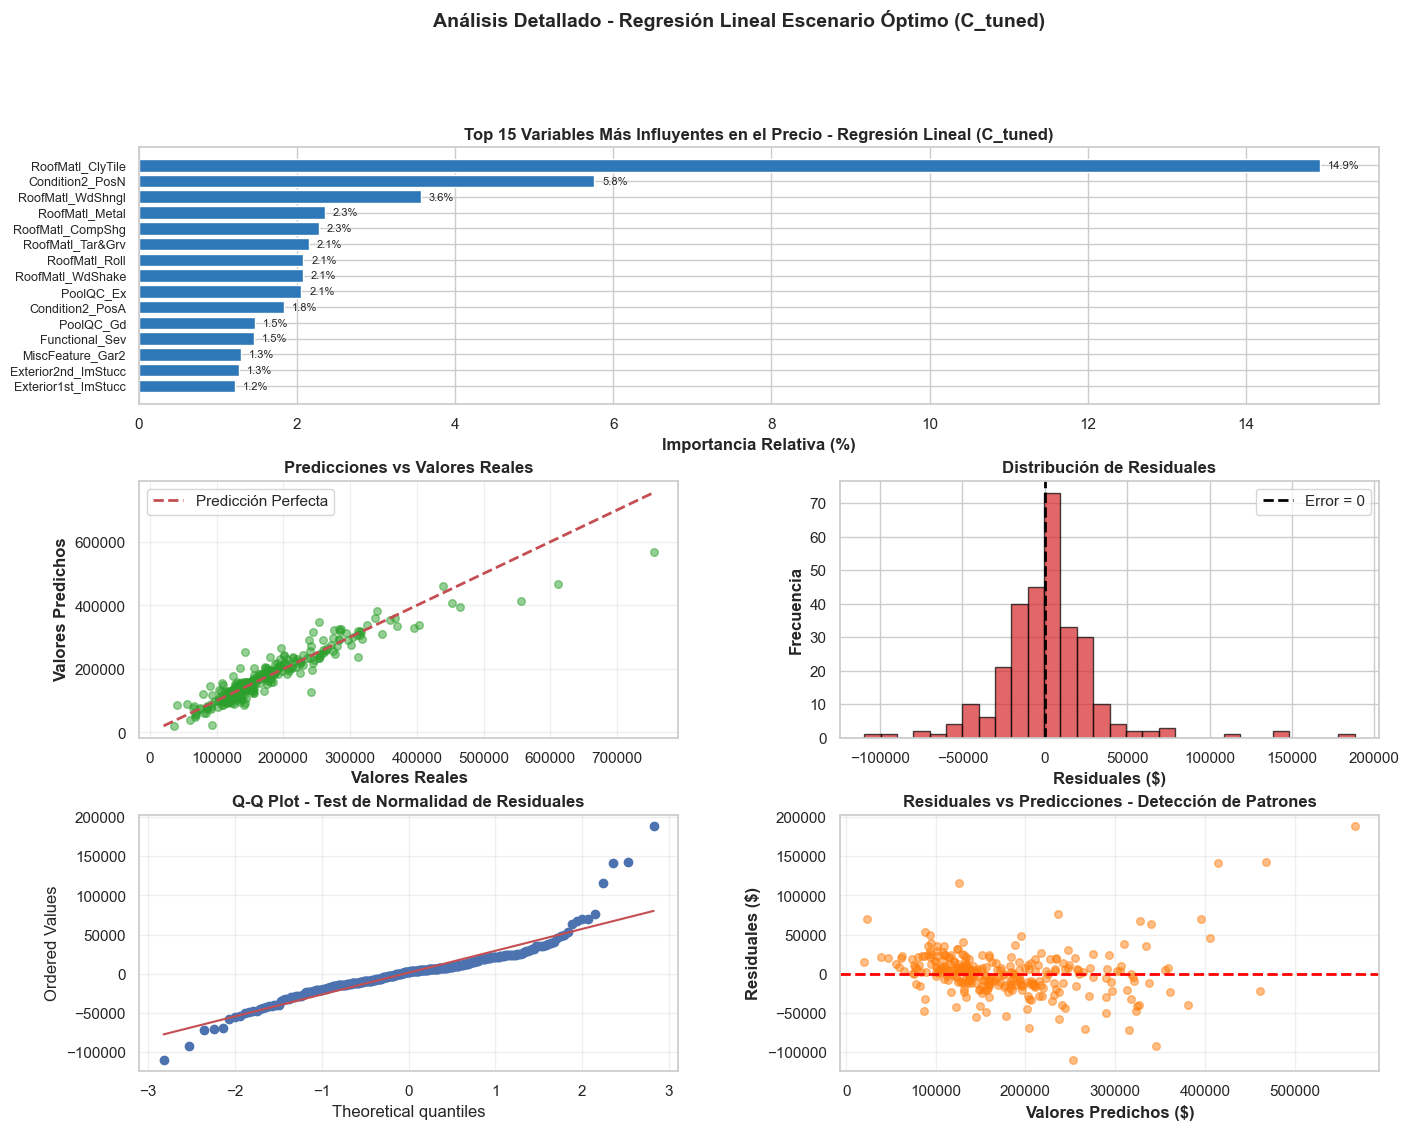

✓ Gráficas de Regresión Lineal guardadas


In [45]:
## Gráficas informativas: Regresión Lineal - Mejor Escenario

# Determinar el mejor escenario (A, B, C)
linear_scenarios = pd.DataFrame([
    {"Escenario": "A_raw", "RMSE": metrics_a["rmse"], "MAPE": metrics_a["mape"]},
    {"Escenario": "B_clean", "RMSE": metrics_b["rmse"], "MAPE": metrics_b["mape"]},
    {"Escenario": "C_tuned", "RMSE": metrics_c["rmse"], "MAPE": metrics_c["mape"]},
])

best_lr_idx = linear_scenarios["RMSE"].idxmin()
best_lr_scenario = linear_scenarios.loc[best_lr_idx, "Escenario"]
best_lr_rmse = linear_scenarios.loc[best_lr_idx, "RMSE"]

print(f"\n📊 Análisis detallado del mejor escenario de Regresión Lineal: {best_lr_scenario} (RMSE: {best_lr_rmse:,.2f})")

# Seleccionar datos del mejor escenario
if best_lr_scenario == "A_raw":
    X_val_lr_plot = X_val_raw
    y_val_lr_plot = y_val_raw
    y_pred_lr_plot = pred_a
    best_lr_model = linear_raw
elif best_lr_scenario == "B_clean":
    X_val_lr_plot = X_val_clean
    y_val_lr_plot = y_val_clean
    y_pred_lr_plot = pred_b
    best_lr_model = linear_clean
else:  # C_tuned
    X_val_lr_plot = X_val_best
    y_val_lr_plot = y_val_best
    y_pred_lr_plot = pred_c
    best_lr_model = best_tuned_model

residuals_lr_plot = y_val_lr_plot - y_pred_lr_plot

# Extraer coeficientes
preprocessor_lr = best_lr_model.named_steps["preprocessor"]
model_lr = best_lr_model.named_steps["model"]

feature_names_lr = []
for name, transformer, columns in preprocessor_lr.transformers_:
    if name == "remainder":
        continue
    if hasattr(transformer, "named_steps"):
        last_step = list(transformer.named_steps.values())[-1]
        if hasattr(last_step, "get_feature_names_out"):
            fn = list(last_step.get_feature_names_out(columns))
        else:
            fn = list(columns)
    else:
        if hasattr(transformer, "get_feature_names_out"):
            fn = list(transformer.get_feature_names_out(columns))
        else:
            fn = list(columns)
    feature_names_lr.extend(fn)

coef_lr = pd.DataFrame({
    "feature": feature_names_lr,
    "coefficient": model_lr.coef_,
})
coef_lr["abs_coefficient"] = coef_lr["coefficient"].abs()
coef_lr["importance_pct"] = (coef_lr["abs_coefficient"] / coef_lr["abs_coefficient"].sum()) * 100
coef_lr = coef_lr.sort_values("importance_pct", ascending=False)
top_15_lr = coef_lr.head(15).sort_values("importance_pct", ascending=True)

# Figure con subplots
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1. Coeficientes Top 15
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.barh(range(len(top_15_lr)), top_15_lr["importance_pct"], color="#2f78b7")
ax1.set_yticks(range(len(top_15_lr)))
ax1.set_yticklabels(top_15_lr["feature"], fontsize=9)
ax1.set_xlabel("Importancia Relativa (%)", fontweight="bold")
ax1.set_title(f"Top 15 Variables Más Influyentes en el Precio - Regresión Lineal ({best_lr_scenario})", fontweight="bold", fontsize=12)

for i, (bar, imp) in enumerate(zip(bars, top_15_lr["importance_pct"])):
    ax1.text(imp + 0.1, bar.get_y() + bar.get_height()/2, f"{imp:.1f}%", va="center", fontsize=8)

# 2. Predicciones vs Reales
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_val_lr_plot, y_pred_lr_plot, alpha=0.5, s=30, color="#2ca02c")
min_val = min(y_val_lr_plot.min(), y_pred_lr_plot.min())
max_val = max(y_val_lr_plot.max(), y_pred_lr_plot.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción Perfecta")
ax2.set_xlabel("Valores Reales", fontweight="bold")
ax2.set_ylabel("Valores Predichos", fontweight="bold")
ax2.set_title("Predicciones vs Valores Reales", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Residuales
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals_lr_plot, bins=30, color="#d62728", alpha=0.7, edgecolor="black")
ax3.axvline(0, color="black", linestyle="--", lw=2, label="Error = 0")
ax3.set_xlabel("Residuales ($)", fontweight="bold")
ax3.set_ylabel("Frecuencia", fontweight="bold")
ax3.set_title("Distribución de Residuales", fontweight="bold")
ax3.legend()

# 4. Q-Q Plot
ax4 = fig.add_subplot(gs[2, 0])
stats.probplot(residuals_lr_plot, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot - Test de Normalidad de Residuales", fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Residuales vs Predicciones
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(y_pred_lr_plot, residuals_lr_plot, alpha=0.5, s=30, color="#ff7f0e")
ax5.axhline(0, color="red", linestyle="--", lw=2)
ax5.set_xlabel("Valores Predichos ($)", fontweight="bold")
ax5.set_ylabel("Residuales ($)", fontweight="bold")
ax5.set_title("Residuales vs Predicciones - Detección de Patrones", fontweight="bold")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Análisis Detallado - Regresión Lineal Escenario Óptimo ({best_lr_scenario})", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
linear_plot_path = ARTIFACTS_DIR / "linear_regression_analysis.png"
plt.savefig(linear_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficas de Regresión Lineal guardadas")


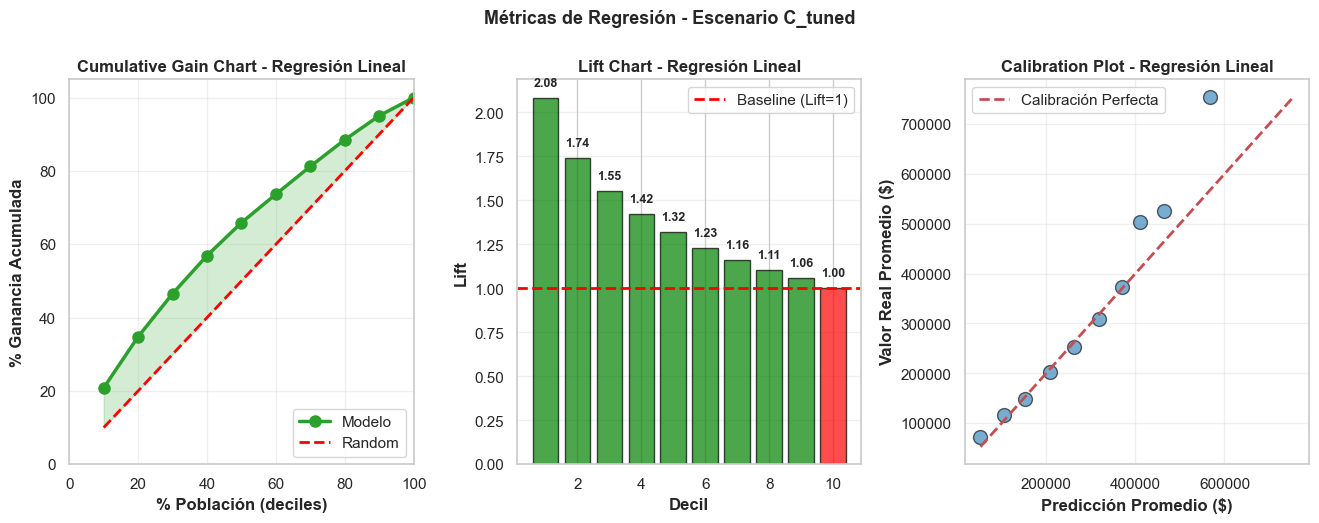

✓ Métricas avanzadas para Regresión Lineal calculadas
  Gain en Decil 1: 20.8%
  Lift promedio: 1.37x


In [46]:
## Métricas Alternativas para Regresión: Cumulative Gain, Lift y Calibración

def generate_regression_metrics_plots(y_true, y_pred, model_name, scenario):
    """Genera Cumulative Gain, Lift Chart y Calibration Plot para modelos de regresión"""
    
    # Crear DataFrame con predicciones y valores reales
    df_metrics = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'error': np.abs(y_true - y_pred),
        'pct_error': np.abs(y_true - y_pred) / y_true * 100
    }).sort_values('y_pred', ascending=False).reset_index(drop=True)
    
    # Dividir en deciles (10 grupos)
    n_deciles = 10
    decile_size = len(df_metrics) // n_deciles
    df_metrics['decile'] = pd.cut(df_metrics.index, bins=n_deciles, labels=range(1, n_deciles+1), duplicates='drop')
    
    # Calcular ganancia acumulada
    decile_summary = df_metrics.groupby('decile').agg({
        'y_true': 'sum',
        'y_pred': 'sum',
        'error': 'mean'
    }).reset_index()
    
    decile_summary['cumulative_gain'] = (decile_summary['y_true'].cumsum() / decile_summary['y_true'].sum() * 100)
    decile_summary['decile_pct'] = np.arange(1, len(decile_summary)+1) * 10
    
    # Baseline: si fuera random
    decile_summary['baseline_gain'] = decile_summary['decile_pct']
    
    # Lift
    decile_summary['lift'] = decile_summary['cumulative_gain'] / decile_summary['baseline_gain']
    
    # Calibración: binning por predicciones, comparar predicted vs actual
    n_bins = 10
    df_calib = pd.DataFrame({
        'predicted_bin': pd.cut(y_pred, bins=n_bins),
        'y_true': y_true,
        'y_pred': y_pred
    })
    
    calib_summary = df_calib.groupby('predicted_bin').agg({
        'y_true': 'mean',
        'y_pred': 'mean'
    }).reset_index()
    calib_summary = calib_summary.dropna()
    
    # Gráficas
    fig = plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. Cumulative Gain Chart
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(decile_summary['decile_pct'], decile_summary['cumulative_gain'], 
             'o-', linewidth=2.5, markersize=8, label='Modelo', color='#2ca02c')
    ax1.plot(decile_summary['decile_pct'], decile_summary['baseline_gain'], 
             '--', linewidth=2, label='Random', color='red')
    ax1.fill_between(decile_summary['decile_pct'], 
                     decile_summary['baseline_gain'], 
                     decile_summary['cumulative_gain'], 
                     alpha=0.2, color='#2ca02c')
    ax1.set_xlabel('% Población (deciles)', fontweight='bold')
    ax1.set_ylabel('% Ganancia Acumulada', fontweight='bold')
    ax1.set_title(f'Cumulative Gain Chart - {model_name}', fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 100)
    ax1.set_ylim(0, 105)
    
    # 2. Lift Chart
    ax2 = fig.add_subplot(gs[0, 1])
    colors_lift = ['green' if x > 1 else 'red' for x in decile_summary['lift']]
    bars = ax2.bar(decile_summary['decile'], decile_summary['lift'], color=colors_lift, alpha=0.7, edgecolor='black')
    ax2.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Baseline (Lift=1)')
    ax2.set_xlabel('Decil', fontweight='bold')
    ax2.set_ylabel('Lift', fontweight='bold')
    ax2.set_title(f'Lift Chart - {model_name}', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, lift) in enumerate(zip(bars, decile_summary['lift'])):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{lift:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 3. Calibration Plot
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(calib_summary['y_pred'], calib_summary['y_true'], s=100, alpha=0.6, color='#1f77b4', edgecolor='black')
    
    # Línea de calibración perfecta
    min_val = min(calib_summary['y_pred'].min(), calib_summary['y_true'].min())
    max_val = max(calib_summary['y_pred'].max(), calib_summary['y_true'].max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Calibración Perfecta')
    
    ax3.set_xlabel('Predicción Promedio ($)', fontweight='bold')
    ax3.set_ylabel('Valor Real Promedio ($)', fontweight='bold')
    ax3.set_title(f'Calibration Plot - {model_name}', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle(f'Métricas de Regresión - Escenario {scenario}', 
                 fontsize=13, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return fig, decile_summary, calib_summary

# Generar para Regresión Lineal (mejor escenario)
fig_lr, decile_lr, calib_lr = generate_regression_metrics_plots(
    y_val_lr_plot, y_pred_lr_plot, 
    'Regresión Lineal', 
    best_lr_scenario
)

plot_lr_path = ARTIFACTS_DIR / "linear_regression_metrics_advanced.png"
plt.savefig(plot_lr_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Métricas avanzadas para Regresión Lineal calculadas")
print(f"  Gain en Decil 1: {decile_lr.loc[0, 'cumulative_gain']:.1f}%")
print(f"  Lift promedio: {decile_lr['lift'].mean():.2f}x")


### 2.3 Ridge

Subseccion preparada para implementacion usando el mismo preprocesador central.

### 2.4 Lasso

Subseccion preparada para implementacion usando el mismo preprocesador central.

### 2.5 Arbol de Decision

Subseccion preparada para implementacion usando el mismo preprocesador central.

In [34]:
## Escenario A: Árbol de Decisión con datos RAW

# Seleccionar el modelo Decision Tree del pipeline de datos raw
dt_raw = pipelines_raw["decision_tree"]

# Entrenar en X_train_raw, y_train_raw
print("Entrenando modelo Decision Tree con datos RAW...")
start_dt_a = time.time()
dt_raw.fit(X_train_raw, y_train_raw)
elapsed_dt_a = time.time() - start_dt_a

# Realizar predicciones en validación
pred_dt_a = dt_raw.predict(X_val_raw)

# Calcular métricas
metrics_dt_a = evaluate_predictions(y_val_raw, pred_dt_a)
metrics_dt_a["fit_seconds"] = elapsed_dt_a

# Registrar en MLflow
mlflow_log_metrics(
    run_name="decision_tree_raw_A",
    params={"model": "DecisionTreeRegressor", "dataset": "raw", "scenario": "A"},
    metrics=metrics_dt_a,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO A (Datos RAW)")
print("="*50)
print(f"RMSE:       {metrics_dt_a['rmse']:,.2f}")
print(f"MAPE:       {metrics_dt_a['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_dt_a:.3f} segundos")
print("="*50)


Entrenando modelo Decision Tree con datos RAW...

RESULTADOS ESCENARIO A (Datos RAW)
RMSE:       41,095.36
MAPE:       16.01%
Tiempo:     0.161 segundos


In [35]:
## Escenario B: Árbol de Decisión con datos CLEAN

# Seleccionar el modelo Decision Tree del pipeline de datos clean
dt_clean = pipelines_clean["decision_tree"]

# Entrenar en X_train_clean, y_train_clean
print("Entrenando modelo Decision Tree con datos CLEAN...")
start_dt_b = time.time()
dt_clean.fit(X_train_clean, y_train_clean)
elapsed_dt_b = time.time() - start_dt_b

# Realizar predicciones en validación
pred_dt_b = dt_clean.predict(X_val_clean)

# Calcular métricas
metrics_dt_b = evaluate_predictions(y_val_clean, pred_dt_b)
metrics_dt_b["fit_seconds"] = elapsed_dt_b

# Registrar en MLflow
mlflow_log_metrics(
    run_name="decision_tree_clean_B",
    params={"model": "DecisionTreeRegressor", "dataset": "clean", "scenario": "B"},
    metrics=metrics_dt_b,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO B (Datos CLEAN)")
print("="*50)
print(f"RMSE:       {metrics_dt_b['rmse']:,.2f}")
print(f"MAPE:       {metrics_dt_b['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_dt_b:.3f} segundos")
print("="*50)


Entrenando modelo Decision Tree con datos CLEAN...

RESULTADOS ESCENARIO B (Datos CLEAN)
RMSE:       42,208.24
MAPE:       15.43%
Tiempo:     0.127 segundos


In [36]:
## Escenario C: Árbol de Decisión con TUNING AVANZADO (GridSearchCV)

# Identificar el mejor escenario entre A y B
dt_scenario_results = pd.DataFrame([
    {"scenario": "A_raw", "rmse": metrics_dt_a["rmse"], "mape": metrics_dt_a["mape"]},
    {"scenario": "B_clean", "rmse": metrics_dt_b["rmse"], "mape": metrics_dt_b["mape"]},
]).sort_values("rmse").reset_index(drop=True)

best_dt_scenario = dt_scenario_results.loc[0, "scenario"]
print(f"Mejor escenario base para tuning (Decision Tree): {best_dt_scenario}")
print(f"  RMSE: {dt_scenario_results.loc[0, 'rmse']:,.2f}")

# Seleccionar datos del mejor escenario
if best_dt_scenario == "A_raw":
    X_train_dt_best, y_train_dt_best = X_train_raw, y_train_raw
    X_val_dt_best, y_val_dt_best = X_val_raw, y_val_raw
    best_dt_pipeline = pipelines_raw["decision_tree"]
    dt_dataset_tag = "raw"
else:
    X_train_dt_best, y_train_dt_best = X_train_clean, y_train_clean
    X_val_dt_best, y_val_dt_best = X_val_clean, y_val_clean
    best_dt_pipeline = pipelines_clean["decision_tree"]
    dt_dataset_tag = "clean"

# Definir grilla de hiperparámetros a buscar (múltiples combinaciones)
dt_param_grid = {
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["squared_error", "absolute_error"],
    "preprocessor__num__imputer__strategy": ["median", "mean"],
}

# Realizar búsqueda con validación cruzada 5-fold
print("\nRealizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...")
dt_grid = GridSearchCV(
    estimator=best_dt_pipeline,
    param_grid=dt_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

start_dt_c = time.time()
dt_grid.fit(X_train_dt_best, y_train_dt_best)
elapsed_dt_c = time.time() - start_dt_c

# Usar el mejor modelo encontrado
best_dt_tuned_model = dt_grid.best_estimator_
pred_dt_c = best_dt_tuned_model.predict(X_val_dt_best)

# Calcular métricas
metrics_dt_c = evaluate_predictions(y_val_dt_best, pred_dt_c)
metrics_dt_c["fit_seconds"] = elapsed_dt_c

# Registrar en MLflow
mlflow_log_metrics(
    run_name="decision_tree_tuned_C",
    params={
        "model": "DecisionTreeRegressor",
        "dataset": dt_dataset_tag,
        "scenario": "C_tuned",
        "best_base_scenario": best_dt_scenario,
        **{f"grid_{k}": str(v) for k, v in dt_grid.best_params_.items()},
    },
    metrics=metrics_dt_c,
    tags={"phase": "tuning"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO C (TUNED con GridSearchCV)")
print("="*50)
print(f"Base: {best_dt_scenario}")
print(f"RMSE:       {metrics_dt_c['rmse']:,.2f}")
print(f"MAPE:       {metrics_dt_c['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_dt_c:.3f} segundos")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in dt_grid.best_params_.items():
    print(f"  {k}: {v}")
print("="*50)


Mejor escenario base para tuning (Decision Tree): A_raw
  RMSE: 41,095.36

Realizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...
Fitting 5 folds for each of 320 candidates, totalling 1600 fits

RESULTADOS ESCENARIO C (TUNED con GridSearchCV)
Base: A_raw
RMSE:       37,116.45
MAPE:       14.46%
Tiempo:     77.434 segundos

Mejores hiperparámetros encontrados:
  model__criterion: absolute_error
  model__max_depth: 10
  model__min_samples_leaf: 8
  model__min_samples_split: 2
  preprocessor__num__imputer__strategy: median


In [37]:
## Consolidación de Resultados: Decision Tree - Comparación de Escenarios

# Crear tabla comparativa
dt_results_comparison = pd.DataFrame([
    {
        "Modelo": "Decision Tree",
        "Escenario": "A_raw",
        "RMSE": metrics_dt_a["rmse"],
        "MAPE (%)": metrics_dt_a["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_dt_a["fit_seconds"],
    },
    {
        "Modelo": "Decision Tree",
        "Escenario": "B_clean",
        "RMSE": metrics_dt_b["rmse"],
        "MAPE (%)": metrics_dt_b["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_dt_b["fit_seconds"],
    },
    {
        "Modelo": "Decision Tree",
        "Escenario": "C_tuned",
        "RMSE": metrics_dt_c["rmse"],
        "MAPE (%)": metrics_dt_c["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_dt_c["fit_seconds"],
    },
])

# Calcular mejora vs baseline
dt_results_comparison["Mejora vs Baseline (%)"] = (
    (baseline_metrics["rmse"] - dt_results_comparison["RMSE"]) / baseline_metrics["rmse"] * 100
)

# Obtener min y max del RMSE
dt_rmse_min = dt_results_comparison["RMSE"].min()
dt_rmse_max = dt_results_comparison["RMSE"].max()

# Mostrar tabla con estilos
display(
    dt_results_comparison.style
    .format({
        "RMSE": "{:,.2f}",
        "MAPE (%)": "{:.2f}%",
        "Tiempo entrenamiento (s)": "{:.3f}",
        "Mejora vs Baseline (%)": "{:.2f}%",
    })
    .map(lambda val: amplify_gradient_color(val, dt_rmse_min, dt_rmse_max), subset=["RMSE"])
    .set_caption("📊 Resumen: Decision Tree - Comparación de Escenarios")
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
)

print("\n✓ Tabla consolidada Decision Tree completada")


Modelo,Escenario,RMSE,MAPE (%),Tiempo entrenamiento (s),Mejora vs Baseline (%)
Decision Tree,A_raw,"41,095.36",16.01%,0.161,53.10%
Decision Tree,B_clean,"42,208.24",15.43%,0.127,51.83%
Decision Tree,C_tuned,"37,116.45",14.46%,77.434,57.64%



✓ Tabla consolidada Decision Tree completada



📊 Análisis detallado del mejor modelo DT: C_tuned (RMSE: 37,116.45)


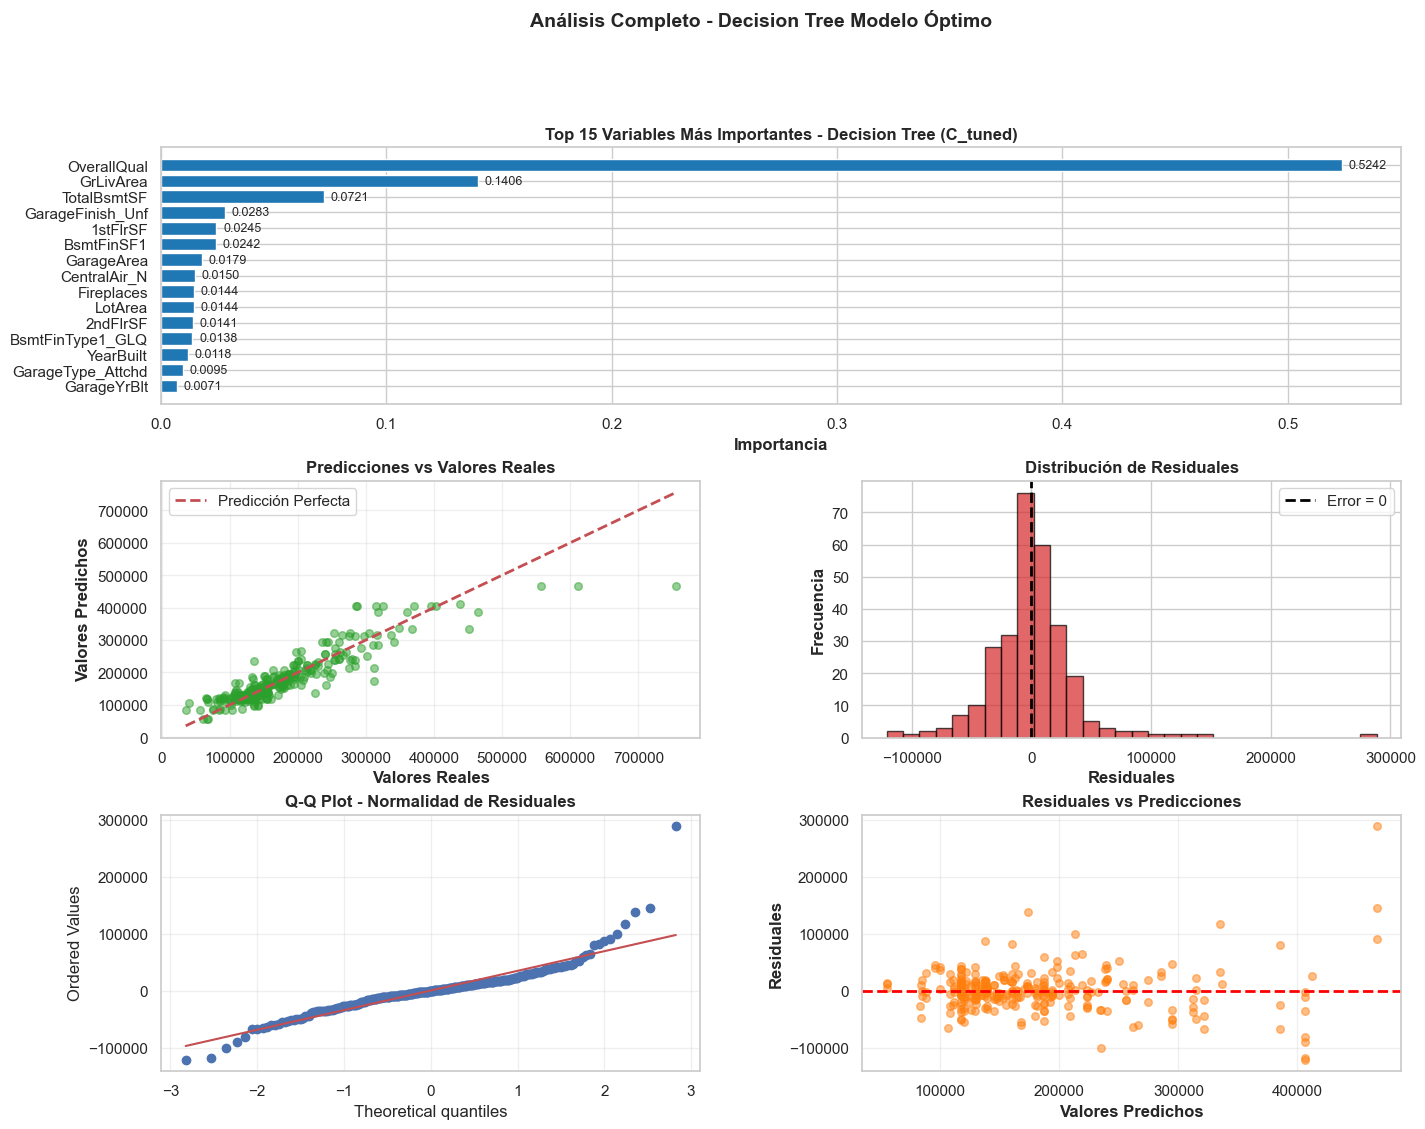

✓ Gráficas de Decision Tree guardadas


In [42]:
import matplotlib.gridspec as gridspec
from scipy import stats

## Gráficas informativas: Decision Tree - Mejor Modelo (Escenario C - Tuned)

# Obtener el mejor modelo entre A, B, C para DT
dt_best_idx = dt_results_comparison["RMSE"].idxmin()
dt_best_scenario = dt_results_comparison.loc[dt_best_idx, "Escenario"]
dt_best_rmse = dt_results_comparison.loc[dt_best_idx, "RMSE"]

print(f"\n📊 Análisis detallado del mejor modelo DT: {dt_best_scenario} (RMSE: {dt_best_rmse:,.2f})")

# Seleccionar el mejor modelo entrenado
if dt_best_scenario == "A_raw":
    best_dt_model = dt_raw
    X_val_analysis_dt = X_val_raw
    y_val_analysis_dt = y_val_raw
    y_pred_analysis_dt = pred_dt_a
elif dt_best_scenario == "B_clean":
    best_dt_model = pipelines_clean["decision_tree"]
    X_val_analysis_dt = X_val_clean
    y_val_analysis_dt = y_val_clean
    y_pred_analysis_dt = pred_dt_b
else:  # C_tuned
    best_dt_model = best_dt_tuned_model
    X_val_analysis_dt = X_val_dt_best
    y_val_analysis_dt = y_val_dt_best
    y_pred_analysis_dt = pred_dt_c

residuals_dt = y_val_analysis_dt - y_pred_analysis_dt

# Figure con subplots: Feature Importance + Pred vs Real + Residuales
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1. Feature Importance (extraído del árbol)
ax1 = fig.add_subplot(gs[0, :])
dt_model_obj = best_dt_model.named_steps["model"]
if hasattr(dt_model_obj, "feature_importances_"):
    dt_feature_names = get_feature_names_from_preprocessor(best_dt_model.named_steps["preprocessor"])
    dt_importances = dt_model_obj.feature_importances_
    
    # Top 15 features
    top_indices = np.argsort(dt_importances)[-15:]
    top_features = [dt_feature_names[i] for i in top_indices]
    top_imps = dt_importances[top_indices]
    
    bars = ax1.barh(range(len(top_features)), top_imps, color="#1f77b4")
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features)
    ax1.set_xlabel("Importancia", fontweight="bold")
    ax1.set_title(f"Top 15 Variables Más Importantes - Decision Tree ({dt_best_scenario})", fontweight="bold", fontsize=12)
    
    for i, (bar, imp) in enumerate(zip(bars, top_imps)):
        ax1.text(imp + 0.003, bar.get_y() + bar.get_height()/2, f"{imp:.4f}", va="center", fontsize=9)

# 2. Predicciones vs Valores Reales
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_val_analysis_dt, y_pred_analysis_dt, alpha=0.5, s=30, color="#2ca02c")
min_val = min(y_val_analysis_dt.min(), y_pred_analysis_dt.min())
max_val = max(y_val_analysis_dt.max(), y_pred_analysis_dt.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción Perfecta")
ax2.set_xlabel("Valores Reales", fontweight="bold")
ax2.set_ylabel("Valores Predichos", fontweight="bold")
ax2.set_title("Predicciones vs Valores Reales", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Residuales
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals_dt, bins=30, color="#d62728", alpha=0.7, edgecolor="black")
ax3.axvline(0, color="black", linestyle="--", lw=2, label="Error = 0")
ax3.set_xlabel("Residuales", fontweight="bold")
ax3.set_ylabel("Frecuencia", fontweight="bold")
ax3.set_title("Distribución de Residuales", fontweight="bold")
ax3.legend()

# 4. Q-Q Plot (Normalidad de residuales)
ax4 = fig.add_subplot(gs[2, 0])
stats.probplot(residuals_dt, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot - Normalidad de Residuales", fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Residuales vs Predicciones
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(y_pred_analysis_dt, residuals_dt, alpha=0.5, s=30, color="#ff7f0e")
ax5.axhline(0, color="red", linestyle="--", lw=2)
ax5.set_xlabel("Valores Predichos", fontweight="bold")
ax5.set_ylabel("Residuales", fontweight="bold")
ax5.set_title("Residuales vs Predicciones", fontweight="bold")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Análisis Completo - Decision Tree Modelo Óptimo", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
dt_plot_path = ARTIFACTS_DIR / "dt_analysis_comprehensive.png"
plt.savefig(dt_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficas de Decision Tree guardadas")


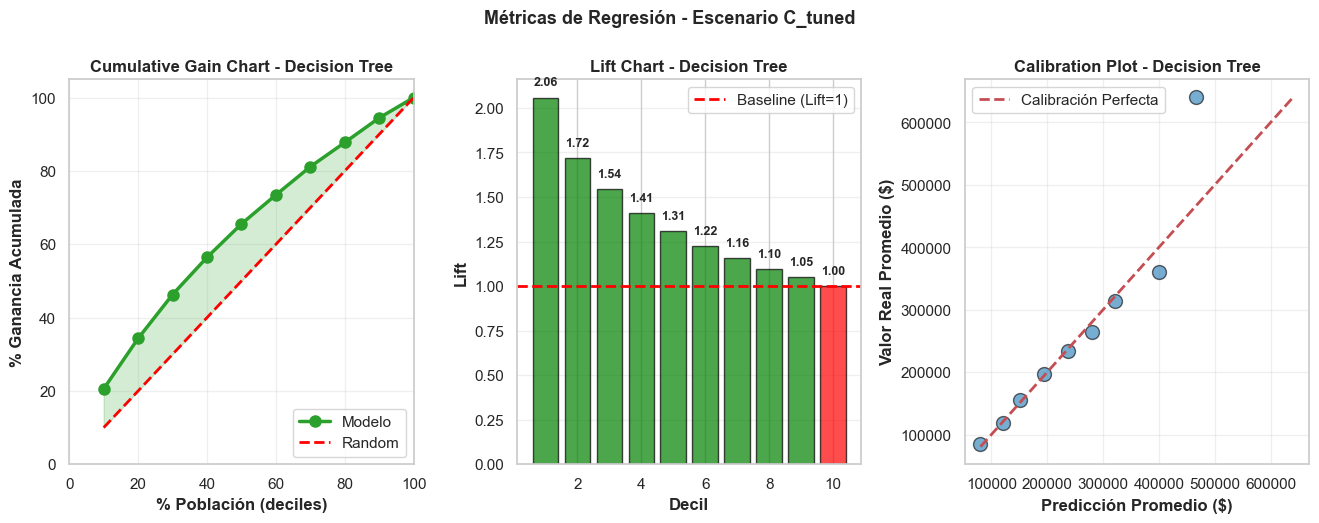

✓ Métricas avanzadas para Decision Tree calculadas
  Gain en Decil 1: 20.6%
  Lift promedio: 1.36x


In [47]:
# Generar para Decision Tree (mejor escenario)
fig_dt, decile_dt, calib_dt = generate_regression_metrics_plots(
    y_val_analysis_dt, y_pred_analysis_dt, 
    'Decision Tree', 
    dt_best_scenario
)

plot_dt_path = ARTIFACTS_DIR / "decision_tree_metrics_advanced.png"
plt.savefig(plot_dt_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Métricas avanzadas para Decision Tree calculadas")
print(f"  Gain en Decil 1: {decile_dt.loc[0, 'cumulative_gain']:.1f}%")
print(f"  Lift promedio: {decile_dt['lift'].mean():.2f}x")


### 2.6 Random Forest

Subseccion preparada para implementacion usando el mismo preprocesador central.

In [38]:
## Escenario A: Random Forest con datos RAW

# Seleccionar el modelo Random Forest del pipeline de datos raw
rf_raw = pipelines_raw["random_forest"]

# Entrenar en X_train_raw, y_train_raw
print("Entrenando modelo Random Forest con datos RAW...")
start_rf_a = time.time()
rf_raw.fit(X_train_raw, y_train_raw)
elapsed_rf_a = time.time() - start_rf_a

# Realizar predicciones en validación
pred_rf_a = rf_raw.predict(X_val_raw)

# Calcular métricas
metrics_rf_a = evaluate_predictions(y_val_raw, pred_rf_a)
metrics_rf_a["fit_seconds"] = elapsed_rf_a

# Registrar en MLflow
mlflow_log_metrics(
    run_name="random_forest_raw_A",
    params={"model": "RandomForestRegressor", "dataset": "raw", "scenario": "A", "n_estimators": 300},
    metrics=metrics_rf_a,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO A (Datos RAW)")
print("="*50)
print(f"RMSE:       {metrics_rf_a['rmse']:,.2f}")
print(f"MAPE:       {metrics_rf_a['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_rf_a:.3f} segundos")
print("="*50)


Entrenando modelo Random Forest con datos RAW...

RESULTADOS ESCENARIO A (Datos RAW)
RMSE:       28,730.44
MAPE:       10.63%
Tiempo:     14.496 segundos


In [39]:
## Escenario B: Random Forest con datos CLEAN

# Seleccionar el modelo Random Forest del pipeline de datos clean
rf_clean = pipelines_clean["random_forest"]

# Entrenar en X_train_clean, y_train_clean
print("Entrenando modelo Random Forest con datos CLEAN...")
start_rf_b = time.time()
rf_clean.fit(X_train_clean, y_train_clean)
elapsed_rf_b = time.time() - start_rf_b

# Realizar predicciones en validación
pred_rf_b = rf_clean.predict(X_val_clean)

# Calcular métricas
metrics_rf_b = evaluate_predictions(y_val_clean, pred_rf_b)
metrics_rf_b["fit_seconds"] = elapsed_rf_b

# Registrar en MLflow
mlflow_log_metrics(
    run_name="random_forest_clean_B",
    params={"model": "RandomForestRegressor", "dataset": "clean", "scenario": "B", "n_estimators": 300},
    metrics=metrics_rf_b,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO B (Datos CLEAN)")
print("="*50)
print(f"RMSE:       {metrics_rf_b['rmse']:,.2f}")
print(f"MAPE:       {metrics_rf_b['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_rf_b:.3f} segundos")
print("="*50)


Entrenando modelo Random Forest con datos CLEAN...

RESULTADOS ESCENARIO B (Datos CLEAN)
RMSE:       28,888.39
MAPE:       10.66%
Tiempo:     10.833 segundos


In [40]:
## Escenario C: Random Forest con TUNING AVANZADO (GridSearchCV)

# Identificar el mejor escenario entre A y B
rf_scenario_results = pd.DataFrame([
    {"scenario": "A_raw", "rmse": metrics_rf_a["rmse"], "mape": metrics_rf_a["mape"]},
    {"scenario": "B_clean", "rmse": metrics_rf_b["rmse"], "mape": metrics_rf_b["mape"]},
]).sort_values("rmse").reset_index(drop=True)

best_rf_scenario = rf_scenario_results.loc[0, "scenario"]
print(f"Mejor escenario base para tuning (Random Forest): {best_rf_scenario}")
print(f"  RMSE: {rf_scenario_results.loc[0, 'rmse']:,.2f}")

# Seleccionar datos del mejor escenario
if best_rf_scenario == "A_raw":
    X_train_rf_best, y_train_rf_best = X_train_raw, y_train_raw
    X_val_rf_best, y_val_rf_best = X_val_raw, y_val_raw
    best_rf_pipeline = pipelines_raw["random_forest"]
    rf_dataset_tag = "raw"
else:
    X_train_rf_best, y_train_rf_best = X_train_clean, y_train_clean
    X_val_rf_best, y_val_rf_best = X_val_clean, y_val_clean
    best_rf_pipeline = pipelines_clean["random_forest"]
    rf_dataset_tag = "clean"

# Definir grilla de hiperparámetros a buscar (múltiples combinaciones)
rf_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "preprocessor__num__imputer__strategy": ["median", "mean"],
}

# Realizar búsqueda con validación cruzada 5-fold
print("\nRealizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...")
rf_grid = GridSearchCV(
    estimator=best_rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

start_rf_c = time.time()
rf_grid.fit(X_train_rf_best, y_train_rf_best)
elapsed_rf_c = time.time() - start_rf_c

# Usar el mejor modelo encontrado
best_rf_tuned_model = rf_grid.best_estimator_
pred_rf_c = best_rf_tuned_model.predict(X_val_rf_best)

# Calcular métricas
metrics_rf_c = evaluate_predictions(y_val_rf_best, pred_rf_c)
metrics_rf_c["fit_seconds"] = elapsed_rf_c

# Registrar en MLflow
mlflow_log_metrics(
    run_name="random_forest_tuned_C",
    params={
        "model": "RandomForestRegressor",
        "dataset": rf_dataset_tag,
        "scenario": "C_tuned",
        "best_base_scenario": best_rf_scenario,
        **{f"grid_{k}": str(v) for k, v in rf_grid.best_params_.items()},
    },
    metrics=metrics_rf_c,
    tags={"phase": "tuning"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO C (TUNED con GridSearchCV)")
print("="*50)
print(f"Base: {best_rf_scenario}")
print(f"RMSE:       {metrics_rf_c['rmse']:,.2f}")
print(f"MAPE:       {metrics_rf_c['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_rf_c:.3f} segundos")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in rf_grid.best_params_.items():
    print(f"  {k}: {v}")
print("="*50)


Mejor escenario base para tuning (Random Forest): A_raw
  RMSE: 28,730.44

Realizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

RESULTADOS ESCENARIO C (TUNED con GridSearchCV)
Base: A_raw
RMSE:       31,971.65
MAPE:       11.33%
Tiempo:     465.077 segundos

Mejores hiperparámetros encontrados:
  model__max_depth: 20
  model__max_features: sqrt
  model__min_samples_leaf: 1
  model__min_samples_split: 2
  model__n_estimators: 200
  preprocessor__num__imputer__strategy: median


In [41]:
## Consolidación de Resultados: Random Forest - Comparación de Escenarios

# Crear tabla comparativa
rf_results_comparison = pd.DataFrame([
    {
        "Modelo": "Random Forest",
        "Escenario": "A_raw",
        "RMSE": metrics_rf_a["rmse"],
        "MAPE (%)": metrics_rf_a["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_rf_a["fit_seconds"],
    },
    {
        "Modelo": "Random Forest",
        "Escenario": "B_clean",
        "RMSE": metrics_rf_b["rmse"],
        "MAPE (%)": metrics_rf_b["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_rf_b["fit_seconds"],
    },
    {
        "Modelo": "Random Forest",
        "Escenario": "C_tuned",
        "RMSE": metrics_rf_c["rmse"],
        "MAPE (%)": metrics_rf_c["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_rf_c["fit_seconds"],
    },
])

# Calcular mejora vs baseline
rf_results_comparison["Mejora vs Baseline (%)"] = (
    (baseline_metrics["rmse"] - rf_results_comparison["RMSE"]) / baseline_metrics["rmse"] * 100
)

# Obtener min y max del RMSE
rf_rmse_min = rf_results_comparison["RMSE"].min()
rf_rmse_max = rf_results_comparison["RMSE"].max()

# Mostrar tabla con estilos
display(
    rf_results_comparison.style
    .format({
        "RMSE": "{:,.2f}",
        "MAPE (%)": "{:.2f}%",
        "Tiempo entrenamiento (s)": "{:.3f}",
        "Mejora vs Baseline (%)": "{:.2f}%",
    })
    .map(lambda val: amplify_gradient_color(val, rf_rmse_min, rf_rmse_max), subset=["RMSE"])
    .set_caption("📊 Resumen: Random Forest - Comparación de Escenarios")
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
)

print("\n✓ Tabla consolidada Random Forest completada")


Modelo,Escenario,RMSE,MAPE (%),Tiempo entrenamiento (s),Mejora vs Baseline (%)
Random Forest,A_raw,"28,730.44",10.63%,14.496,67.21%
Random Forest,B_clean,"28,888.39",10.66%,10.833,67.03%
Random Forest,C_tuned,"31,971.65",11.33%,465.077,63.51%



✓ Tabla consolidada Random Forest completada



📊 Análisis detallado del mejor modelo RF: A_raw (RMSE: 28,730.44)


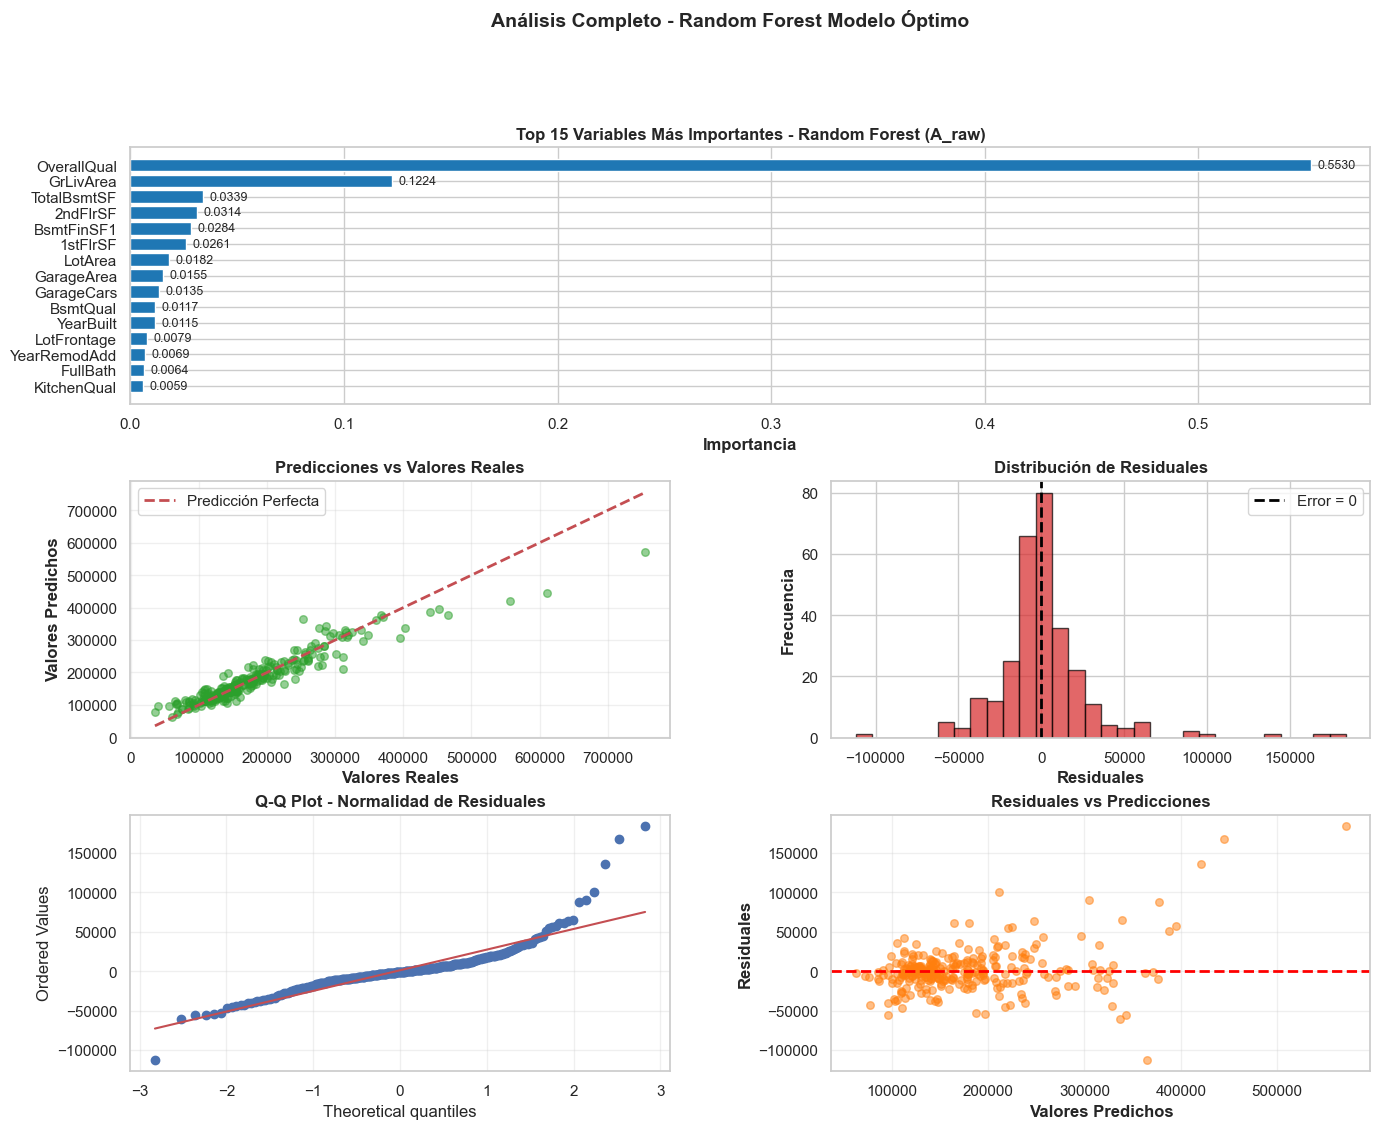

✓ Gráficas de Random Forest guardadas


In [43]:
## Gráficas informativas: Random Forest - Mejor Modelo (Escenario C - Tuned)

# Obtener el mejor modelo entre A, B, C para RF
rf_best_idx = rf_results_comparison["RMSE"].idxmin()
rf_best_scenario = rf_results_comparison.loc[rf_best_idx, "Escenario"]
rf_best_rmse = rf_results_comparison.loc[rf_best_idx, "RMSE"]

print(f"\n📊 Análisis detallado del mejor modelo RF: {rf_best_scenario} (RMSE: {rf_best_rmse:,.2f})")

# Seleccionar el mejor modelo entrenado
if rf_best_scenario == "A_raw":
    best_rf_model = rf_raw
    X_val_analysis_rf = X_val_raw
    y_val_analysis_rf = y_val_raw
    y_pred_analysis_rf = pred_rf_a
elif rf_best_scenario == "B_clean":
    best_rf_model = pipelines_clean["random_forest"]
    X_val_analysis_rf = X_val_clean
    y_val_analysis_rf = y_val_clean
    y_pred_analysis_rf = pred_rf_b
else:  # C_tuned
    best_rf_model = best_rf_tuned_model
    X_val_analysis_rf = X_val_rf_best
    y_val_analysis_rf = y_val_rf_best
    y_pred_analysis_rf = pred_rf_c

residuals_rf = y_val_analysis_rf - y_pred_analysis_rf

# Figure con subplots: Feature Importance + Pred vs Real + Residuales
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1. Feature Importance
ax1 = fig.add_subplot(gs[0, :])
rf_model_obj = best_rf_model.named_steps["model"]
if hasattr(rf_model_obj, "feature_importances_"):
    rf_feature_names = get_feature_names_from_preprocessor(best_rf_model.named_steps["preprocessor"])
    rf_importances = rf_model_obj.feature_importances_
    
    # Top 15 features
    top_indices = np.argsort(rf_importances)[-15:]
    top_features = [rf_feature_names[i] for i in top_indices]
    top_imps = rf_importances[top_indices]
    
    bars = ax1.barh(range(len(top_features)), top_imps, color="#1f77b4")
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features)
    ax1.set_xlabel("Importancia", fontweight="bold")
    ax1.set_title(f"Top 15 Variables Más Importantes - Random Forest ({rf_best_scenario})", fontweight="bold", fontsize=12)
    
    for i, (bar, imp) in enumerate(zip(bars, top_imps)):
        ax1.text(imp + 0.003, bar.get_y() + bar.get_height()/2, f"{imp:.4f}", va="center", fontsize=9)

# 2. Predicciones vs Valores Reales
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_val_analysis_rf, y_pred_analysis_rf, alpha=0.5, s=30, color="#2ca02c")
min_val = min(y_val_analysis_rf.min(), y_pred_analysis_rf.min())
max_val = max(y_val_analysis_rf.max(), y_pred_analysis_rf.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción Perfecta")
ax2.set_xlabel("Valores Reales", fontweight="bold")
ax2.set_ylabel("Valores Predichos", fontweight="bold")
ax2.set_title("Predicciones vs Valores Reales", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Residuales
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals_rf, bins=30, color="#d62728", alpha=0.7, edgecolor="black")
ax3.axvline(0, color="black", linestyle="--", lw=2, label="Error = 0")
ax3.set_xlabel("Residuales", fontweight="bold")
ax3.set_ylabel("Frecuencia", fontweight="bold")
ax3.set_title("Distribución de Residuales", fontweight="bold")
ax3.legend()

# 4. Q-Q Plot (Normalidad de residuales)
ax4 = fig.add_subplot(gs[2, 0])
stats.probplot(residuals_rf, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot - Normalidad de Residuales", fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Residuales vs Predicciones
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(y_pred_analysis_rf, residuals_rf, alpha=0.5, s=30, color="#ff7f0e")
ax5.axhline(0, color="red", linestyle="--", lw=2)
ax5.set_xlabel("Valores Predichos", fontweight="bold")
ax5.set_ylabel("Residuales", fontweight="bold")
ax5.set_title("Residuales vs Predicciones", fontweight="bold")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Análisis Completo - Random Forest Modelo Óptimo", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
rf_plot_path = ARTIFACTS_DIR / "rf_analysis_comprehensive.png"
plt.savefig(rf_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficas de Random Forest guardadas")


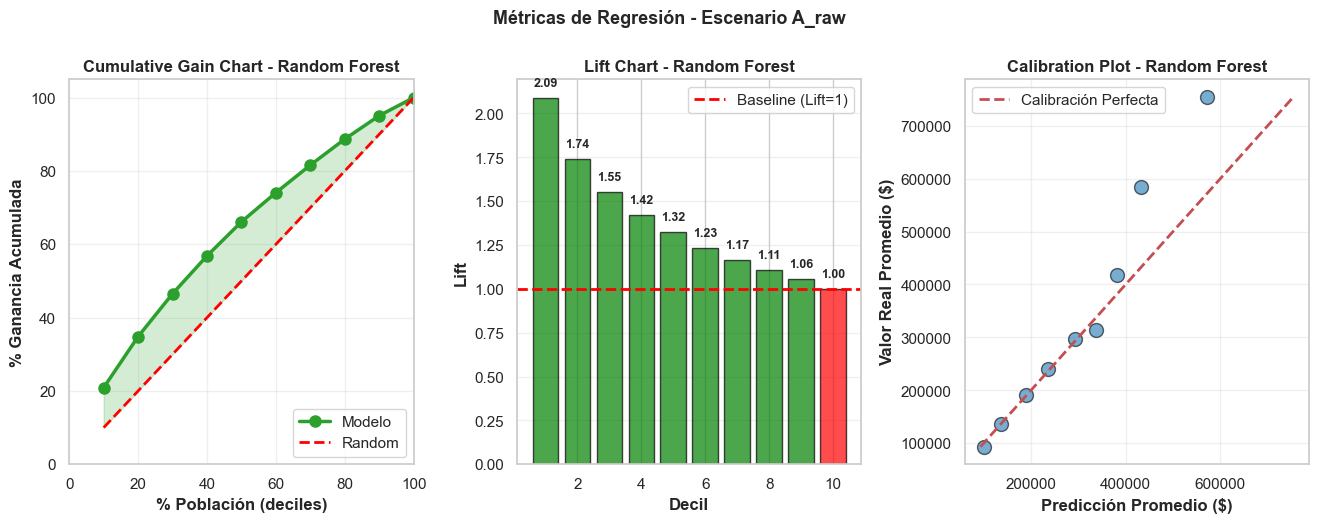

✓ Métricas avanzadas para Random Forest calculadas
  Gain en Decil 1: 20.9%
  Lift promedio: 1.37x


In [48]:
# Generar para Random Forest (mejor escenario)
fig_rf, decile_rf, calib_rf = generate_regression_metrics_plots(
    y_val_analysis_rf, y_pred_analysis_rf, 
    'Random Forest', 
    rf_best_scenario
)

plot_rf_path = ARTIFACTS_DIR / "random_forest_metrics_advanced.png"
plt.savefig(plot_rf_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Métricas avanzadas para Random Forest calculadas")
print(f"  Gain en Decil 1: {decile_rf.loc[0, 'cumulative_gain']:.1f}%")
print(f"  Lift promedio: {decile_rf['lift'].mean():.2f}x")


### 2.7 Gradient Boosting

Subseccion preparada para implementacion usando el mismo preprocesador central.

### 2.8 XGBoost

Implementación de XGBoost con comparación de datos RAW vs CLEAN y tuning avanzado con GridSearchCV.

In [90]:
## Escenario A: XGBoost con datos RAW

# Seleccionar el modelo XGBoost del pipeline de datos raw
xgb_raw = pipelines_raw["xgboost"]

# Entrenar en X_train_raw, y_train_raw
print("Entrenando modelo XGBoost con datos RAW...")
start_xgb_a = time.time()
xgb_raw.fit(X_train_raw, y_train_raw)
elapsed_xgb_a = time.time() - start_xgb_a

# Realizar predicciones en validación
xgb_pred_a = xgb_raw.predict(X_val_raw)

# Calcular métricas
metrics_xgb_a = evaluate_predictions(y_val_raw, xgb_pred_a)
metrics_xgb_a["fit_seconds"] = elapsed_xgb_a

# Registrar en MLflow
mlflow_log_metrics(
    run_name="xgboost_raw_A",
    params={"model": "XGBRegressor", "dataset": "raw", "scenario": "A"},
    metrics=metrics_xgb_a,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO A (Datos RAW)")
print("="*50)
print(f"RMSE:       {metrics_xgb_a['rmse']:,.2f}")
print(f"MAPE:       {metrics_xgb_a['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_xgb_a:.3f} segundos")
print("="*50)

Entrenando modelo XGBoost con datos RAW...

RESULTADOS ESCENARIO A (Datos RAW)
RMSE:       27,393.68
MAPE:       11.07%
Tiempo:     0.990 segundos


In [91]:
## Escenario B: XGBoost con datos CLEAN

# Seleccionar el modelo XGBoost del pipeline de datos clean
xgb_clean = pipelines_clean["xgboost"]

# Entrenar en X_train_clean, y_train_clean
print("Entrenando modelo XGBoost con datos CLEAN...")
start_xgb_b = time.time()
xgb_clean.fit(X_train_clean, y_train_clean)
elapsed_xgb_b = time.time() - start_xgb_b

# Realizar predicciones en validación
xgb_pred_b = xgb_clean.predict(X_val_clean)

# Calcular métricas
metrics_xgb_b = evaluate_predictions(y_val_clean, xgb_pred_b)
metrics_xgb_b["fit_seconds"] = elapsed_xgb_b

# Registrar en MLflow
mlflow_log_metrics(
    run_name="xgboost_clean_B",
    params={"model": "XGBRegressor", "dataset": "clean", "scenario": "B"},
    metrics=metrics_xgb_b,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO B (Datos CLEAN)")
print("="*50)
print(f"RMSE:       {metrics_xgb_b['rmse']:,.2f}")
print(f"MAPE:       {metrics_xgb_b['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_xgb_b:.3f} segundos")
print("="*50)

Entrenando modelo XGBoost con datos CLEAN...

RESULTADOS ESCENARIO B (Datos CLEAN)
RMSE:       29,261.00
MAPE:       10.90%
Tiempo:     0.805 segundos


In [92]:
## Escenario C: XGBoost con TUNING AVANZADO (GridSearchCV)

# Identificar el mejor escenario entre A y B
xgb_scenario_results = pd.DataFrame([
    {"scenario": "A_raw", "rmse": metrics_xgb_a["rmse"], "mape": metrics_xgb_a["mape"]},
    {"scenario": "B_clean", "rmse": metrics_xgb_b["rmse"], "mape": metrics_xgb_b["mape"]},
]).sort_values("rmse").reset_index(drop=True)

best_xgb_scenario = xgb_scenario_results.loc[0, "scenario"]
print(f"Mejor escenario base para tuning (XGBoost): {best_xgb_scenario}")
print(f"  RMSE: {xgb_scenario_results.loc[0, 'rmse']:,.2f}")

# Seleccionar datos del mejor escenario
if best_xgb_scenario == "A_raw":
    X_train_xgb_best, y_train_xgb_best = X_train_raw, y_train_raw
    X_val_xgb_best, y_val_xgb_best = X_val_raw, y_val_raw
    best_xgb_pipeline = pipelines_raw["xgboost"]
    xgb_dataset_tag = "raw"
else:
    X_train_xgb_best, y_train_xgb_best = X_train_clean, y_train_clean
    X_val_xgb_best, y_val_xgb_best = X_val_clean, y_val_clean
    best_xgb_pipeline = pipelines_clean["xgboost"]
    xgb_dataset_tag = "clean"

# Definir grilla de hiperparámetros a buscar
xgb_param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [100, 200, 300],
    "model__subsample": [0.8, 0.9, 1.0],
}

# Realizar búsqueda con validación cruzada 5-fold
print("\nRealizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...")
xgb_grid = GridSearchCV(
    estimator=best_xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

start_xgb_c = time.time()
xgb_grid.fit(X_train_xgb_best, y_train_xgb_best)
elapsed_xgb_c = time.time() - start_xgb_c

# Usar el mejor modelo encontrado
best_xgb_tuned_model = xgb_grid.best_estimator_
xgb_pred_c = best_xgb_tuned_model.predict(X_val_xgb_best)

# Calcular métricas
metrics_xgb_c = evaluate_predictions(y_val_xgb_best, xgb_pred_c)
metrics_xgb_c["fit_seconds"] = elapsed_xgb_c

# Registrar en MLflow
mlflow_log_metrics(
    run_name="xgboost_tuned_C",
    params={
        "model": "XGBRegressor",
        "dataset": xgb_dataset_tag,
        "scenario": "C_tuned",
        "best_base_scenario": best_xgb_scenario,
        **{f"grid_{k}": str(v) for k, v in xgb_grid.best_params_.items()},
    },
    metrics=metrics_xgb_c,
    tags={"phase": "tuning"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO C (TUNED con GridSearchCV)")
print("="*50)
print(f"Base: {best_xgb_scenario}")
print(f"RMSE:       {metrics_xgb_c['rmse']:,.2f}")
print(f"MAPE:       {metrics_xgb_c['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_xgb_c:.3f} segundos")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in xgb_grid.best_params_.items():
    print(f"  {k}: {v}")
print("="*50)

Mejor escenario base para tuning (XGBoost): A_raw
  RMSE: 27,393.68

Realizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

RESULTADOS ESCENARIO C (TUNED con GridSearchCV)
Base: A_raw
RMSE:       26,252.77
MAPE:       9.46%
Tiempo:     73.807 segundos

Mejores hiperparámetros encontrados:
  model__learning_rate: 0.1
  model__max_depth: 3
  model__n_estimators: 300
  model__subsample: 0.9


In [93]:
## Consolidación de Resultados: XGBoost - Comparación de Escenarios

# Actualizar resultados con el escenario C
xgb_results_comparison = pd.DataFrame([
    {
        "Modelo": "XGBoost",
        "Escenario": "A_raw",
        "RMSE": metrics_xgb_a["rmse"],
        "MAPE (%)": metrics_xgb_a["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_xgb_a["fit_seconds"],
    },
    {
        "Modelo": "XGBoost",
        "Escenario": "B_clean",
        "RMSE": metrics_xgb_b["rmse"],
        "MAPE (%)": metrics_xgb_b["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_xgb_b["fit_seconds"],
    },
    {
        "Modelo": "XGBoost",
        "Escenario": "C_tuned",
        "RMSE": metrics_xgb_c["rmse"],
        "MAPE (%)": metrics_xgb_c["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_xgb_c["fit_seconds"],
    },
])

# Calcular mejora vs baseline
xgb_results_comparison["Mejora vs Baseline (%)"] = (
    (baseline_metrics["rmse"] - xgb_results_comparison["RMSE"]) / baseline_metrics["rmse"] * 100
)

# Obtener min y max del RMSE
xgb_rmse_min = xgb_results_comparison["RMSE"].min()
xgb_rmse_max = xgb_results_comparison["RMSE"].max()

# Mostrar tabla con estilos
display(
    xgb_results_comparison.style
    .format({
        "RMSE": "{:,.2f}",
        "MAPE (%)": "{:.2f}%",
        "Tiempo entrenamiento (s)": "{:.3f}",
        "Mejora vs Baseline (%)": "{:.2f}%",
    })
    .background_gradient(cmap="RdYlGn_r", subset=["RMSE"], vmin=xgb_rmse_min, vmax=xgb_rmse_max, axis=None)
    .set_caption("📊 Resumen: XGBoost - Comparación de Escenarios")
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
)

print("\n✓ Tabla consolidada XGBoost completada")

Modelo,Escenario,RMSE,MAPE (%),Tiempo entrenamiento (s),Mejora vs Baseline (%)
XGBoost,A_raw,"27,393.68",11.07%,0.990,68.74%
XGBoost,B_clean,"29,261.00",10.90%,0.805,66.60%
XGBoost,C_tuned,"26,252.77",9.46%,73.807,70.04%



✓ Tabla consolidada XGBoost completada



📊 Análisis detallado del mejor modelo XGBoost: C_tuned (RMSE: 26,252.77)


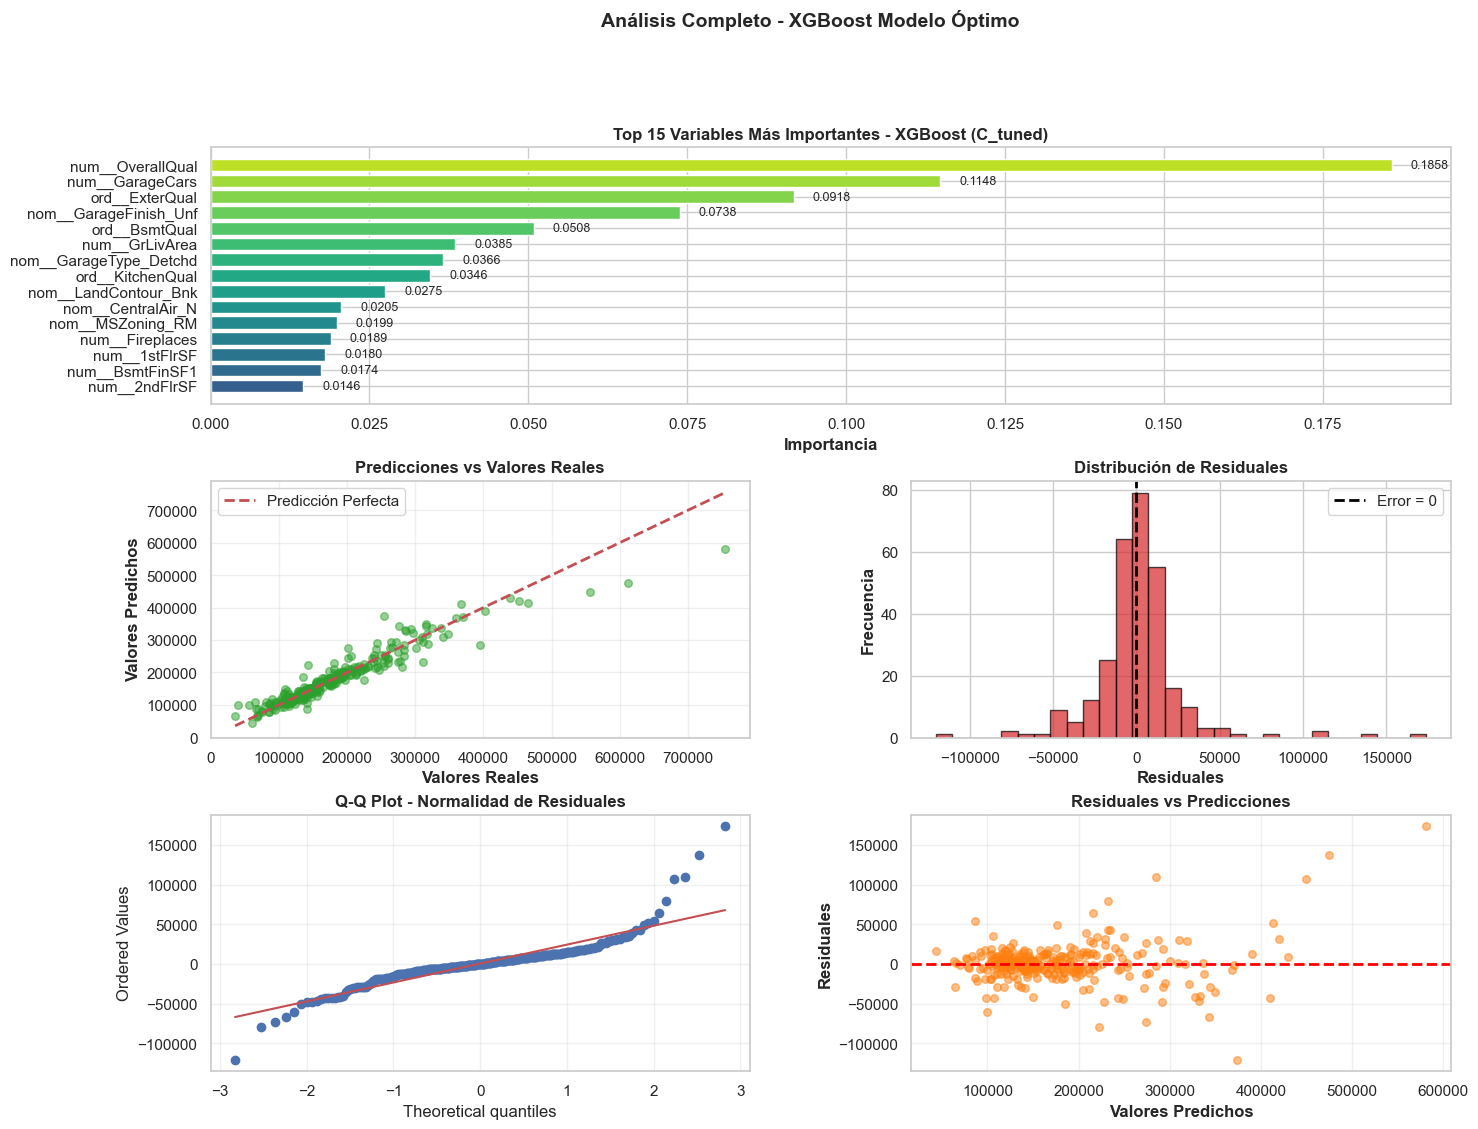

✓ Gráficas de XGBoost guardadas


In [118]:
## Gráficas informativas: XGBoost - Mejor Modelo

# Obtener el mejor modelo entre A, B, C para XGBoost
xgb_best_idx = xgb_results_comparison["RMSE"].idxmin()
xgb_best_scenario = xgb_results_comparison.loc[xgb_best_idx, "Escenario"]
xgb_best_rmse = xgb_results_comparison.loc[xgb_best_idx, "RMSE"]

print(f"\n📊 Análisis detallado del mejor modelo XGBoost: {xgb_best_scenario} (RMSE: {xgb_best_rmse:,.2f})")

# Seleccionar el mejor modelo entrenado
if xgb_best_scenario == "A_raw":
    best_xgb_model = xgb_raw
    X_val_xgb = X_val_raw
    y_val_xgb = y_val_raw
    y_pred_xgb = xgb_pred_a
elif xgb_best_scenario == "B_clean":
    best_xgb_model = xgb_clean
    X_val_xgb = X_val_clean
    y_val_xgb = y_val_clean
    y_pred_xgb = xgb_pred_b
else:  # C_tuned
    best_xgb_model = best_xgb_tuned_model
    X_val_xgb = X_val_xgb_best
    y_val_xgb = y_val_xgb_best
    y_pred_xgb = xgb_pred_c

residuals_xgb = y_val_xgb - y_pred_xgb

# Figure con subplots: Feature Importance + Pred vs Real + Residuales
fig_xgb = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig_xgb, hspace=0.3, wspace=0.3)

# 1. Feature Importance (extraído del modelo XGBoost)
ax1 = fig_xgb.add_subplot(gs[0, :])
xgb_model_obj = best_xgb_model.named_steps["model"]
if hasattr(xgb_model_obj, "feature_importances_"):
    xgb_feature_names = list(best_xgb_model.named_steps["preprocessor"].get_feature_names_out())
    xgb_importances = xgb_model_obj.feature_importances_
    
    # Top 15 features
    top_indices = np.argsort(xgb_importances)[-15:]
    top_features = [xgb_feature_names[i] for i in top_indices]
    top_imps = xgb_importances[top_indices]
    
    colors_xgb = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    bars = ax1.barh(range(len(top_features)), top_imps, color=colors_xgb)
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features)
    ax1.set_xlabel("Importancia", fontweight="bold")
    ax1.set_title(f"Top 15 Variables Más Importantes - XGBoost ({xgb_best_scenario})", fontweight="bold", fontsize=12)
    
    for i, (bar, imp) in enumerate(zip(bars, top_imps)):
        ax1.text(imp + 0.003, bar.get_y() + bar.get_height()/2, f"{imp:.4f}", va="center", fontsize=9)

# 2. Predicciones vs Valores Reales
ax2 = fig_xgb.add_subplot(gs[1, 0])
ax2.scatter(y_val_xgb, y_pred_xgb, alpha=0.5, s=30, color="#2ca02c")
min_val = min(y_val_xgb.min(), y_pred_xgb.min())
max_val = max(y_val_xgb.max(), y_pred_xgb.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción Perfecta")
ax2.set_xlabel("Valores Reales", fontweight="bold")
ax2.set_ylabel("Valores Predichos", fontweight="bold")
ax2.set_title("Predicciones vs Valores Reales", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Residuales
ax3 = fig_xgb.add_subplot(gs[1, 1])
ax3.hist(residuals_xgb, bins=30, color="#d62728", alpha=0.7, edgecolor="black")
ax3.axvline(0, color="black", linestyle="--", lw=2, label="Error = 0")
ax3.set_xlabel("Residuales", fontweight="bold")
ax3.set_ylabel("Frecuencia", fontweight="bold")
ax3.set_title("Distribución de Residuales", fontweight="bold")
ax3.legend()

# 4. Q-Q Plot (Normalidad de residuales)
ax4 = fig_xgb.add_subplot(gs[2, 0])
stats.probplot(residuals_xgb, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot - Normalidad de Residuales", fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Residuales vs Predicciones
ax5 = fig_xgb.add_subplot(gs[2, 1])
ax5.scatter(y_pred_xgb, residuals_xgb, alpha=0.5, s=30, color="#ff7f0e")
ax5.axhline(0, color="red", linestyle="--", lw=2)
ax5.set_xlabel("Valores Predichos", fontweight="bold")
ax5.set_ylabel("Residuales", fontweight="bold")
ax5.set_title("Residuales vs Predicciones", fontweight="bold")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Análisis Completo - XGBoost Modelo Óptimo", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
xgb_plot_path = ARTIFACTS_DIR / "xgboost_analysis_comprehensive.png"
plt.savefig(xgb_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficas de XGBoost guardadas")

In [119]:
# Generar métricas avanzadas para XGBoost
fig_xgb_adv, decile_xgb, calib_xgb = generate_regression_metrics_plots(
    y_val_xgb, y_pred_xgb, 
    'XGBoost', 
    ARTIFACTS_DIR
)

plot_xgb_path = ARTIFACTS_DIR / "xgboost_metrics_advanced.png"
plt.savefig(plot_xgb_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Métricas avanzadas para XGBoost calculadas")
print(f"Gain en Decil 1: {decile_xgb.iloc[0]['cumulative_gain']:.1f}%")
print(f"Lift en Decil 1: {decile_xgb.iloc[0]['lift']:.2f}x")

✓ Saved: xgboost_metrics_advanced.png
  Gain en Decil 1: 20.1%
  Average Lift: 1.36x


<Figure size 640x480 with 0 Axes>

✓ Métricas avanzadas para XGBoost calculadas
Gain en Decil 1: 20.1%
Lift en Decil 1: 2.01x


### 2.9 Light GBM

Implementación de LightGBM con comparación de datos RAW vs CLEAN y tuning avanzado con GridSearchCV.

In [ ]:
## Escenario A: LightGBM con datos RAW

# Seleccionar el modelo LightGBM del pipeline de datos raw
lgb_raw = pipelines_raw["lightgbm"]

# Entrenar en X_train_raw, y_train_raw
print("Entrenando modelo LightGBM con datos RAW...")
start_lgb_a = time.time()
lgb_raw.fit(X_train_raw, y_train_raw)
elapsed_lgb_a = time.time() - start_lgb_a

# Realizar predicciones en validación
lgb_pred_a = lgb_raw.predict(X_val_raw)

# Calcular métricas
metrics_lgb_a = evaluate_predictions(y_val_raw, lgb_pred_a)
metrics_lgb_a["fit_seconds"] = elapsed_lgb_a

# Registrar en MLflow
mlflow_log_metrics(
    run_name="lightgbm_raw_A",
    params={"model": "LGBMRegressor", "dataset": "raw", "scenario": "A"},
    metrics=metrics_lgb_a,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO A (Datos RAW)")
print("="*50)
print(f"RMSE:       {metrics_lgb_a['rmse']:,.2f}")
print(f"MAPE:       {metrics_lgb_a['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_lgb_a:.3f} segundos")
print("="*50)

In [ ]:
## Escenario B: LightGBM con datos CLEAN

# Seleccionar el modelo LightGBM del pipeline de datos clean
lgb_clean = pipelines_clean["lightgbm"]

# Entrenar en X_train_clean, y_train_clean
print("Entrenando modelo LightGBM con datos CLEAN...")
start_lgb_b = time.time()
lgb_clean.fit(X_train_clean, y_train_clean)
elapsed_lgb_b = time.time() - start_lgb_b

# Realizar predicciones en validación
lgb_pred_b = lgb_clean.predict(X_val_clean)

# Calcular métricas
metrics_lgb_b = evaluate_predictions(y_val_clean, lgb_pred_b)
metrics_lgb_b["fit_seconds"] = elapsed_lgb_b

# Registrar en MLflow
mlflow_log_metrics(
    run_name="lightgbm_clean_B",
    params={"model": "LGBMRegressor", "dataset": "clean", "scenario": "B"},
    metrics=metrics_lgb_b,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO B (Datos CLEAN)")
print("="*50)
print(f"RMSE:       {metrics_lgb_b['rmse']:,.2f}")
print(f"MAPE:       {metrics_lgb_b['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_lgb_b:.3f} segundos")
print("="*50)

In [84]:
## Consolidación de Resultados: LightGBM - Comparación de Escenarios

# Crear tabla comparativa
lgb_results_comparison = pd.DataFrame([
    {
        "Modelo": "LightGBM",
        "Escenario": "A_raw",
        "RMSE": metrics_lgb_a["rmse"],
        "MAPE (%)": metrics_lgb_a["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_lgb_a["fit_seconds"],
    },
    {
        "Modelo": "LightGBM",
        "Escenario": "B_clean",
        "RMSE": metrics_lgb_b["rmse"],
        "MAPE (%)": metrics_lgb_b["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_lgb_b["fit_seconds"],
    },
    {
        "Modelo": "LightGBM",
        "Escenario": "C_tuned",
        "RMSE": metrics_lgb_c["rmse"],
        "MAPE (%)": metrics_lgb_c["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_lgb_c["fit_seconds"],
    },
])

# Calcular mejora vs baseline
lgb_results_comparison["Mejora vs Baseline (%)"] = (
    (baseline_metrics["rmse"] - lgb_results_comparison["RMSE"]) / baseline_metrics["rmse"] * 100
)

# Obtener min y max del RMSE
lgb_rmse_min = lgb_results_comparison["RMSE"].min()
lgb_rmse_max = lgb_results_comparison["RMSE"].max()

# Mostrar tabla con estilos
display(
    lgb_results_comparison.style
    .format({
        "RMSE": "{:,.2f}",
        "MAPE (%)": "{:.2f}%",
        "Tiempo entrenamiento (s)": "{:.3f}",
        "Mejora vs Baseline (%)": "{:.2f}%",
    })
    .background_gradient(cmap="RdYlGn_r", subset=["RMSE"], vmin=lgb_rmse_min, vmax=lgb_rmse_max, axis=None)
    .set_caption("📊 Resumen: LightGBM - Comparación de Escenarios")
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
)

print("\n✓ Tabla consolidada LightGBM completada")

Modelo,Escenario,RMSE,MAPE (%),Tiempo entrenamiento (s),Mejora vs Baseline (%)
LightGBM,A_raw,"30,038.19",10.54%,0.564,65.72%
LightGBM,B_clean,"30,333.76",10.29%,0.445,65.38%
LightGBM,C_tuned,"29,396.01",9.87%,57.584,66.45%



✓ Tabla consolidada LightGBM completada


In [66]:
## Escenario C: LightGBM con TUNING AVANZADO (GridSearchCV)

# Identificar el mejor escenario entre A y B
lgb_scenario_results = pd.DataFrame([
    {"scenario": "A_raw", "rmse": metrics_lgb_a["rmse"], "mape": metrics_lgb_a["mape"]},
    {"scenario": "B_clean", "rmse": metrics_lgb_b["rmse"], "mape": metrics_lgb_b["mape"]},
]).sort_values("rmse").reset_index(drop=True)

best_lgb_scenario = lgb_scenario_results.loc[0, "scenario"]
print(f"Mejor escenario base para tuning (LightGBM): {best_lgb_scenario}")
print(f"  RMSE: {lgb_scenario_results.loc[0, 'rmse']:,.2f}")

# Seleccionar datos del mejor escenario
if best_lgb_scenario == "A_raw":
    X_train_lgb_best, y_train_lgb_best = X_train_raw, y_train_raw
    X_val_lgb_best, y_val_lgb_best = X_val_raw, y_val_raw
    best_lgb_pipeline = pipelines_raw["lightgbm"]
    lgb_dataset_tag = "raw"
else:
    X_train_lgb_best, y_train_lgb_best = X_train_clean, y_train_clean
    X_val_lgb_best, y_val_lgb_best = X_val_clean, y_val_clean
    best_lgb_pipeline = pipelines_clean["lightgbm"]
    lgb_dataset_tag = "clean"

# Definir grilla de hiperparámetros a buscar
lgb_param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [100, 200, 300],
    "model__num_leaves": [20, 31, 50],
}

# Realizar búsqueda con validación cruzada 5-fold
print("\nRealizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...")
lgb_grid = GridSearchCV(
    estimator=best_lgb_pipeline,
    param_grid=lgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

start_lgb_c = time.time()
lgb_grid.fit(X_train_lgb_best, y_train_lgb_best)
elapsed_lgb_c = time.time() - start_lgb_c

# Usar el mejor modelo encontrado
best_lgb_tuned_model = lgb_grid.best_estimator_
lgb_pred_c = best_lgb_tuned_model.predict(X_val_lgb_best)

# Calcular métricas
metrics_lgb_c = evaluate_predictions(y_val_lgb_best, lgb_pred_c)
metrics_lgb_c["fit_seconds"] = elapsed_lgb_c

# Registrar en MLflow
mlflow_log_metrics(
    run_name="lightgbm_tuned_C",
    params={
        "model": "LGBMRegressor",
        "dataset": lgb_dataset_tag,
        "scenario": "C_tuned",
        "best_base_scenario": best_lgb_scenario,
        **{f"grid_{k}": str(v) for k, v in lgb_grid.best_params_.items()},
    },
    metrics=metrics_lgb_c,
    tags={"phase": "tuning"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO C (TUNED con GridSearchCV)")
print("="*50)
print(f"Base: {best_lgb_scenario}")
print(f"RMSE:       {metrics_lgb_c['rmse']:,.2f}")
print(f"MAPE:       {metrics_lgb_c['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_lgb_c:.3f} segundos")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in lgb_grid.best_params_.items():
    print(f"  {k}: {v}")
print("="*50)

Mejor escenario base para tuning (LightGBM): A_raw
  RMSE: 30,038.19

Realizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

RESULTADOS ESCENARIO C (TUNED con GridSearchCV)
Base: A_raw
RMSE:       29,396.01
MAPE:       9.87%
Tiempo:     57.584 segundos

Mejores hiperparámetros encontrados:
  model__learning_rate: 0.1
  model__max_depth: 3
  model__n_estimators: 300
  model__num_leaves: 20



📊 Análisis detallado del mejor modelo LightGBM: C_tuned (RMSE: 29,396.01)


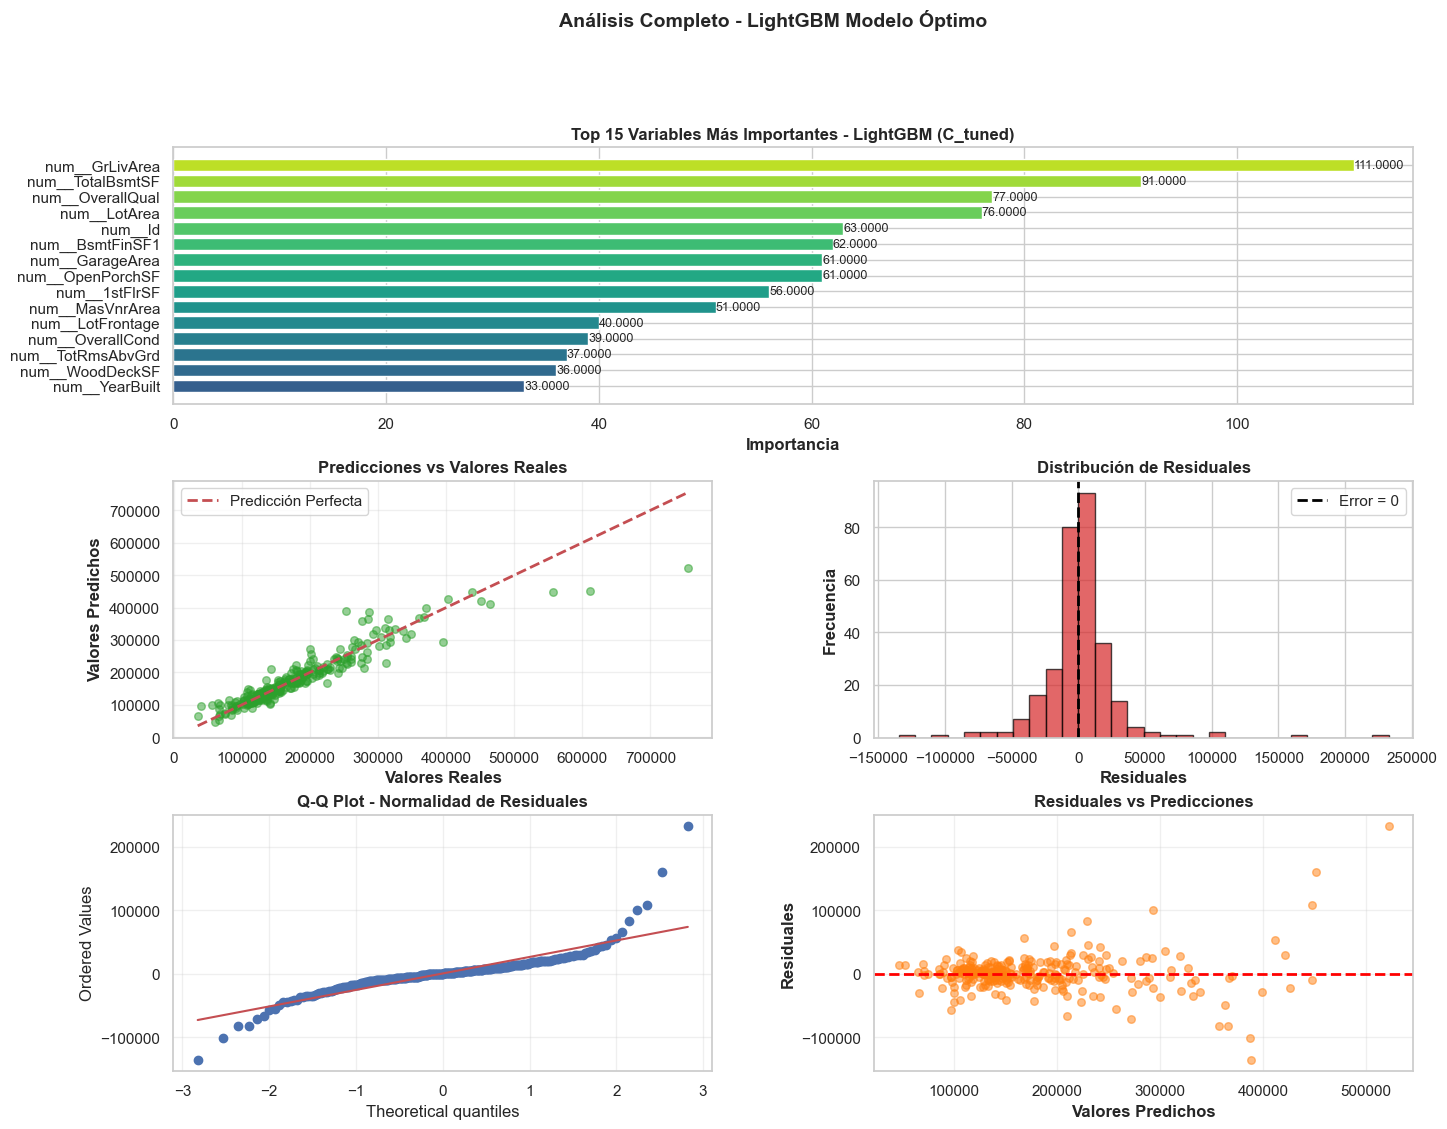

✓ Gráficas de LightGBM guardadas


In [120]:
## Gráficas informativas: LightGBM - Mejor Modelo

# Obtener el mejor modelo entre A, B, C para LightGBM
lgb_best_idx = lgb_results_comparison["RMSE"].idxmin()
lgb_best_scenario = lgb_results_comparison.loc[lgb_best_idx, "Escenario"]
lgb_best_rmse = lgb_results_comparison.loc[lgb_best_idx, "RMSE"]

print(f"\n📊 Análisis detallado del mejor modelo LightGBM: {lgb_best_scenario} (RMSE: {lgb_best_rmse:,.2f})")

# Seleccionar el mejor modelo entrenado
if lgb_best_scenario == "A_raw":
    best_lgb_model = lgb_raw
    X_val_lgb = X_val_raw
    y_val_lgb = y_val_raw
    y_pred_lgb = lgb_pred_a
elif lgb_best_scenario == "B_clean":
    best_lgb_model = lgb_clean
    X_val_lgb = X_val_clean
    y_val_lgb = y_val_clean
    y_pred_lgb = lgb_pred_b
else:  # C_tuned
    best_lgb_model = best_lgb_tuned_model
    X_val_lgb = X_val_lgb_best
    y_val_lgb = y_val_lgb_best
    y_pred_lgb = lgb_pred_c

residuals_lgb = y_val_lgb - y_pred_lgb

# Figure con subplots: Feature Importance + Pred vs Real + Residuales
fig_lgb = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig_lgb, hspace=0.3, wspace=0.3)

# 1. Feature Importance (extraído del modelo LightGBM)
ax1 = fig_lgb.add_subplot(gs[0, :])
lgb_model_obj = best_lgb_model.named_steps["model"]
if hasattr(lgb_model_obj, "feature_importances_"):
    lgb_feature_names = list(best_lgb_model.named_steps["preprocessor"].get_feature_names_out())
    lgb_importances = lgb_model_obj.feature_importances_
    
    # Top 15 features
    top_indices = np.argsort(lgb_importances)[-15:]
    top_features = [lgb_feature_names[i] for i in top_indices]
    top_imps = lgb_importances[top_indices]
    
    colors_lgb = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    bars = ax1.barh(range(len(top_features)), top_imps, color=colors_lgb)
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features)
    ax1.set_xlabel("Importancia", fontweight="bold")
    ax1.set_title(f"Top 15 Variables Más Importantes - LightGBM ({lgb_best_scenario})", fontweight="bold", fontsize=12)
    
    for i, (bar, imp) in enumerate(zip(bars, top_imps)):
        ax1.text(imp + 0.003, bar.get_y() + bar.get_height()/2, f"{imp:.4f}", va="center", fontsize=9)

# 2. Predicciones vs Valores Reales
ax2 = fig_lgb.add_subplot(gs[1, 0])
ax2.scatter(y_val_lgb, y_pred_lgb, alpha=0.5, s=30, color="#2ca02c")
min_val = min(y_val_lgb.min(), y_pred_lgb.min())
max_val = max(y_val_lgb.max(), y_pred_lgb.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción Perfecta")
ax2.set_xlabel("Valores Reales", fontweight="bold")
ax2.set_ylabel("Valores Predichos", fontweight="bold")
ax2.set_title("Predicciones vs Valores Reales", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Residuales
ax3 = fig_lgb.add_subplot(gs[1, 1])
ax3.hist(residuals_lgb, bins=30, color="#d62728", alpha=0.7, edgecolor="black")
ax3.axvline(0, color="black", linestyle="--", lw=2, label="Error = 0")
ax3.set_xlabel("Residuales", fontweight="bold")
ax3.set_ylabel("Frecuencia", fontweight="bold")
ax3.set_title("Distribución de Residuales", fontweight="bold")
ax3.legend()

# 4. Q-Q Plot (Normalidad de residuales)
ax4 = fig_lgb.add_subplot(gs[2, 0])
stats.probplot(residuals_lgb, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot - Normalidad de Residuales", fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Residuales vs Predicciones
ax5 = fig_lgb.add_subplot(gs[2, 1])
ax5.scatter(y_pred_lgb, residuals_lgb, alpha=0.5, s=30, color="#ff7f0e")
ax5.axhline(0, color="red", linestyle="--", lw=2)
ax5.set_xlabel("Valores Predichos", fontweight="bold")
ax5.set_ylabel("Residuales", fontweight="bold")
ax5.set_title("Residuales vs Predicciones", fontweight="bold")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Análisis Completo - LightGBM Modelo Óptimo", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
lgb_plot_path = ARTIFACTS_DIR / "lightgbm_analysis_comprehensive.png"
plt.savefig(lgb_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficas de LightGBM guardadas")

In [ ]:
# Generar métricas avanzadas para LightGBM
fig_lgb_adv, decile_lgb, calib_lgb = generate_regression_metrics_plots(
    y_val_lgb, y_pred_lgb, 
    'LightGBM', 
    ARTIFACTS_DIR
)

plot_lgb_path = ARTIFACTS_DIR / "lightgbm_metrics_advanced.png"
plt.savefig(plot_lgb_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Métricas avanzadas para LightGBM calculadas")
print(f"Gain en Decil 1: {decile_lgb.iloc[0]['cumulative_gain']:.1f}%")
print(f"Lift en Decil 1: {decile_lgb.iloc[0]['lift']:.2f}x")

### 2.10 CatBoost

Implementación de CatBoost con comparación de datos RAW vs CLEAN y tuning avanzado con GridSearchCV.

In [ ]:
## Escenario A: CatBoost con datos RAW

# Seleccionar el modelo CatBoost del pipeline de datos raw
cat_raw = pipelines_raw["catboost"]

# Entrenar en X_train_raw, y_train_raw
print("Entrenando modelo CatBoost con datos RAW...")
start_cat_a = time.time()
cat_raw.fit(X_train_raw, y_train_raw)
elapsed_cat_a = time.time() - start_cat_a

# Realizar predicciones en validación
cat_pred_a = cat_raw.predict(X_val_raw)

# Calcular métricas
metrics_cat_a = evaluate_predictions(y_val_raw, cat_pred_a)
metrics_cat_a["fit_seconds"] = elapsed_cat_a

# Registrar en MLflow
mlflow_log_metrics(
    run_name="catboost_raw_A",
    params={"model": "CatBoostRegressor", "dataset": "raw", "scenario": "A"},
    metrics=metrics_cat_a,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO A (Datos RAW)")
print("="*50)
print(f"RMSE:       {metrics_cat_a['rmse']:,.2f}")
print(f"MAPE:       {metrics_cat_a['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_cat_a:.3f} segundos")
print("="*50)

In [ ]:
## Escenario B: CatBoost con datos CLEAN

# Seleccionar el modelo CatBoost del pipeline de datos clean
cat_clean = pipelines_clean["catboost"]

# Entrenar en X_train_clean, y_train_clean
print("Entrenando modelo CatBoost con datos CLEAN...")
start_cat_b = time.time()
cat_clean.fit(X_train_clean, y_train_clean)
elapsed_cat_b = time.time() - start_cat_b

# Realizar predicciones en validación
cat_pred_b = cat_clean.predict(X_val_clean)

# Calcular métricas
metrics_cat_b = evaluate_predictions(y_val_clean, cat_pred_b)
metrics_cat_b["fit_seconds"] = elapsed_cat_b

# Registrar en MLflow
mlflow_log_metrics(
    run_name="catboost_clean_B",
    params={"model": "CatBoostRegressor", "dataset": "clean", "scenario": "B"},
    metrics=metrics_cat_b,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO B (Datos CLEAN)")
print("="*50)
print(f"RMSE:       {metrics_cat_b['rmse']:,.2f}")
print(f"MAPE:       {metrics_cat_b['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_cat_b:.3f} segundos")
print("="*50)

In [85]:
## Consolidación de Resultados: CatBoost - Comparación de Escenarios

# Crear tabla comparativa
cat_results_comparison = pd.DataFrame([
    {
        "Modelo": "CatBoost",
        "Escenario": "A_raw",
        "RMSE": metrics_cat_a["rmse"],
        "MAPE (%)": metrics_cat_a["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_cat_a["fit_seconds"],
    },
    {
        "Modelo": "CatBoost",
        "Escenario": "B_clean",
        "RMSE": metrics_cat_b["rmse"],
        "MAPE (%)": metrics_cat_b["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_cat_b["fit_seconds"],
    },
    {
        "Modelo": "CatBoost",
        "Escenario": "C_tuned",
        "RMSE": metrics_cat_c["rmse"],
        "MAPE (%)": metrics_cat_c["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_cat_c["fit_seconds"],
    },
])

# Calcular mejora vs baseline
cat_results_comparison["Mejora vs Baseline (%)"] = (
    (baseline_metrics["rmse"] - cat_results_comparison["RMSE"]) / baseline_metrics["rmse"] * 100
)

# Obtener min y max del RMSE
cat_rmse_min = cat_results_comparison["RMSE"].min()
cat_rmse_max = cat_results_comparison["RMSE"].max()

# Mostrar tabla con estilos
display(
    cat_results_comparison.style
    .format({
        "RMSE": "{:,.2f}",
        "MAPE (%)": "{:.2f}%",
        "Tiempo entrenamiento (s)": "{:.3f}",
        "Mejora vs Baseline (%)": "{:.2f}%",
    })
    .background_gradient(cmap="RdYlGn_r", subset=["RMSE"], vmin=cat_rmse_min, vmax=cat_rmse_max, axis=None)
    .set_caption("📊 Resumen: CatBoost - Comparación de Escenarios")
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
)

print("\n✓ Tabla consolidada CatBoost completada")

Modelo,Escenario,RMSE,MAPE (%),Tiempo entrenamiento (s),Mejora vs Baseline (%)
CatBoost,A_raw,"25,539.31",9.26%,1.490,70.85%
CatBoost,B_clean,"29,095.35",9.75%,1.642,66.79%
CatBoost,C_tuned,"26,124.61",9.76%,202.797,70.18%



✓ Tabla consolidada CatBoost completada


In [79]:
## Escenario C: CatBoost con TUNING AVANZADO (GridSearchCV)

# Identificar el mejor escenario entre A y B
cat_scenario_results = pd.DataFrame([
    {"scenario": "A_raw", "rmse": metrics_cat_a["rmse"], "mape": metrics_cat_a["mape"]},
    {"scenario": "B_clean", "rmse": metrics_cat_b["rmse"], "mape": metrics_cat_b["mape"]},
]).sort_values("rmse").reset_index(drop=True)

best_cat_scenario = cat_scenario_results.loc[0, "scenario"]
print(f"Mejor escenario base para tuning (CatBoost): {best_cat_scenario}")
print(f"  RMSE: {cat_scenario_results.loc[0, 'rmse']:,.2f}")

# Seleccionar datos del mejor escenario
if best_cat_scenario == "A_raw":
    X_train_cat_best, y_train_cat_best = X_train_raw, y_train_raw
    X_val_cat_best, y_val_cat_best = X_val_raw, y_val_raw
    best_cat_pipeline = pipelines_raw["catboost"]
    cat_dataset_tag = "raw"
else:
    X_train_cat_best, y_train_cat_best = X_train_clean, y_train_clean
    X_val_cat_best, y_val_cat_best = X_val_clean, y_val_clean
    best_cat_pipeline = pipelines_clean["catboost"]
    cat_dataset_tag = "clean"

# Definir grilla de hiperparámetros a buscar
cat_param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__depth": [3, 5, 7],
    "model__n_estimators": [100, 200, 300],
    "model__l2_leaf_reg": [1, 3, 5],
}

# Realizar búsqueda con validación cruzada 5-fold
print("\nRealizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...")
cat_grid = GridSearchCV(
    estimator=best_cat_pipeline,
    param_grid=cat_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

start_cat_c = time.time()
cat_grid.fit(X_train_cat_best, y_train_cat_best)
elapsed_cat_c = time.time() - start_cat_c

# Usar el mejor modelo encontrado
best_cat_tuned_model = cat_grid.best_estimator_
cat_pred_c = best_cat_tuned_model.predict(X_val_cat_best)

# Calcular métricas
metrics_cat_c = evaluate_predictions(y_val_cat_best, cat_pred_c)
metrics_cat_c["fit_seconds"] = elapsed_cat_c

# Registrar en MLflow
mlflow_log_metrics(
    run_name="catboost_tuned_C",
    params={
        "model": "CatBoostRegressor",
        "dataset": cat_dataset_tag,
        "scenario": "C_tuned",
        "best_base_scenario": best_cat_scenario,
        **{f"grid_{k}": str(v) for k, v in cat_grid.best_params_.items()},
    },
    metrics=metrics_cat_c,
    tags={"phase": "tuning"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO C (TUNED con GridSearchCV)")
print("="*50)
print(f"Base: {best_cat_scenario}")
print(f"RMSE:       {metrics_cat_c['rmse']:,.2f}")
print(f"MAPE:       {metrics_cat_c['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_cat_c:.3f} segundos")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in cat_grid.best_params_.items():
    print(f"  {k}: {v}")
print("="*50)

Mejor escenario base para tuning (CatBoost): A_raw
  RMSE: 25,539.31

Realizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

RESULTADOS ESCENARIO C (TUNED con GridSearchCV)
Base: A_raw
RMSE:       26,124.61
MAPE:       9.76%
Tiempo:     202.797 segundos

Mejores hiperparámetros encontrados:
  model__depth: 3
  model__l2_leaf_reg: 1
  model__learning_rate: 0.1
  model__n_estimators: 300



📊 Análisis detallado del mejor modelo CatBoost: A_raw (RMSE: 25,539.31)


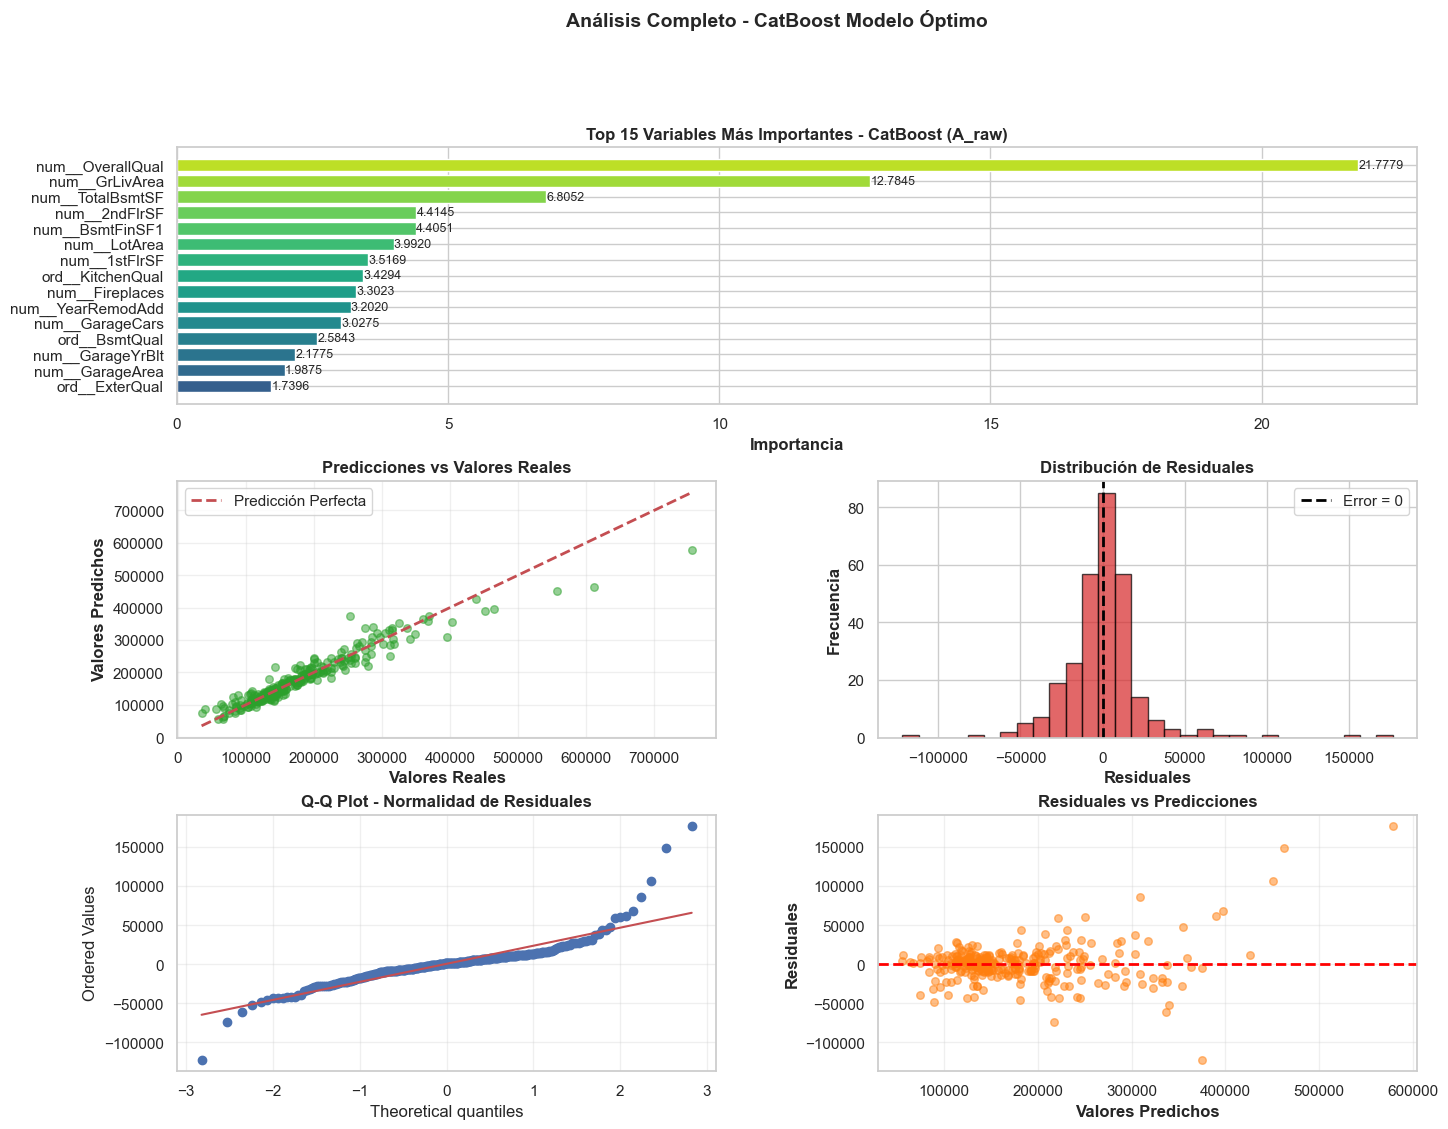

✓ Gráficas de CatBoost guardadas


In [121]:
## Gráficas informativas: CatBoost - Mejor Modelo

# Obtener el mejor modelo entre A, B, C para CatBoost
cat_best_idx = cat_results_comparison["RMSE"].idxmin()
cat_best_scenario = cat_results_comparison.loc[cat_best_idx, "Escenario"]
cat_best_rmse = cat_results_comparison.loc[cat_best_idx, "RMSE"]

print(f"\n📊 Análisis detallado del mejor modelo CatBoost: {cat_best_scenario} (RMSE: {cat_best_rmse:,.2f})")

# Seleccionar el mejor modelo entrenado
if cat_best_scenario == "A_raw":
    best_cat_model = cat_raw
    X_val_cat = X_val_raw
    y_val_cat = y_val_raw
    y_pred_cat = cat_pred_a
elif cat_best_scenario == "B_clean":
    best_cat_model = cat_clean
    X_val_cat = X_val_clean
    y_val_cat = y_val_clean
    y_pred_cat = cat_pred_b
else:  # C_tuned
    best_cat_model = best_cat_tuned_model
    X_val_cat = X_val_cat_best
    y_val_cat = y_val_cat_best
    y_pred_cat = cat_pred_c

residuals_cat = y_val_cat - y_pred_cat

# Figure con subplots: Feature Importance + Pred vs Real + Residuales
fig_cat = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig_cat, hspace=0.3, wspace=0.3)

# 1. Feature Importance (extraído del modelo CatBoost)
ax1 = fig_cat.add_subplot(gs[0, :])
cat_model_obj = best_cat_model.named_steps["model"]
if hasattr(cat_model_obj, "feature_importances_"):
    cat_feature_names = list(best_cat_model.named_steps["preprocessor"].get_feature_names_out())
    cat_importances = cat_model_obj.feature_importances_
    
    # Top 15 features
    top_indices = np.argsort(cat_importances)[-15:]
    top_features = [cat_feature_names[i] for i in top_indices]
    top_imps = cat_importances[top_indices]
    
    colors_cat = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    bars = ax1.barh(range(len(top_features)), top_imps, color=colors_cat)
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features)
    ax1.set_xlabel("Importancia", fontweight="bold")
    ax1.set_title(f"Top 15 Variables Más Importantes - CatBoost ({cat_best_scenario})", fontweight="bold", fontsize=12)
    
    for i, (bar, imp) in enumerate(zip(bars, top_imps)):
        ax1.text(imp + 0.003, bar.get_y() + bar.get_height()/2, f"{imp:.4f}", va="center", fontsize=9)

# 2. Predicciones vs Valores Reales
ax2 = fig_cat.add_subplot(gs[1, 0])
ax2.scatter(y_val_cat, y_pred_cat, alpha=0.5, s=30, color="#2ca02c")
min_val = min(y_val_cat.min(), y_pred_cat.min())
max_val = max(y_val_cat.max(), y_pred_cat.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción Perfecta")
ax2.set_xlabel("Valores Reales", fontweight="bold")
ax2.set_ylabel("Valores Predichos", fontweight="bold")
ax2.set_title("Predicciones vs Valores Reales", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Residuales
ax3 = fig_cat.add_subplot(gs[1, 1])
ax3.hist(residuals_cat, bins=30, color="#d62728", alpha=0.7, edgecolor="black")
ax3.axvline(0, color="black", linestyle="--", lw=2, label="Error = 0")
ax3.set_xlabel("Residuales", fontweight="bold")
ax3.set_ylabel("Frecuencia", fontweight="bold")
ax3.set_title("Distribución de Residuales", fontweight="bold")
ax3.legend()

# 4. Q-Q Plot (Normalidad de residuales)
ax4 = fig_cat.add_subplot(gs[2, 0])
stats.probplot(residuals_cat, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot - Normalidad de Residuales", fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Residuales vs Predicciones
ax5 = fig_cat.add_subplot(gs[2, 1])
ax5.scatter(y_pred_cat, residuals_cat, alpha=0.5, s=30, color="#ff7f0e")
ax5.axhline(0, color="red", linestyle="--", lw=2)
ax5.set_xlabel("Valores Predichos", fontweight="bold")
ax5.set_ylabel("Residuales", fontweight="bold")
ax5.set_title("Residuales vs Predicciones", fontweight="bold")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Análisis Completo - CatBoost Modelo Óptimo", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
cat_plot_path = ARTIFACTS_DIR / "catboost_analysis_comprehensive.png"
plt.savefig(cat_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficas de CatBoost guardadas")

In [ ]:
# Generar métricas avanzadas para CatBoost
fig_cat_adv, decile_cat, calib_cat = generate_regression_metrics_plots(
    y_val_cat, y_pred_cat, 
    'CatBoost', 
    ARTIFACTS_DIR
)

plot_cat_path = ARTIFACTS_DIR / "catboost_metrics_advanced.png"
plt.savefig(plot_cat_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Métricas avanzadas para CatBoost calculadas")
print(f"Gain en Decil 1: {decile_cat.iloc[0]['cumulative_gain']:.1f}%")
print(f"Lift en Decil 1: {decile_cat.iloc[0]['lift']:.2f}x")

In [ ]:
## Gráficas informativas: CatBoost - Mejor Modelo

# Obtener el mejor modelo entre A, B, C para CatBoost
cat_best_idx = cat_results_comparison["RMSE"].idxmin()
cat_best_scenario = cat_results_comparison.loc[cat_best_idx, "Escenario"]
cat_best_rmse = cat_results_comparison.loc[cat_best_idx, "RMSE"]

print(f"\n📊 Análisis detallado del mejor modelo CatBoost: {cat_best_scenario} (RMSE: {cat_best_rmse:,.2f})")

# Seleccionar el mejor modelo entrenado
if cat_best_scenario == "A_raw":
    best_cat_model = cat_raw
    X_val_cat = X_val_raw
    y_val_cat = y_val_raw
    y_pred_cat = cat_pred_a
elif cat_best_scenario == "B_clean":
    best_cat_model = cat_clean
    X_val_cat = X_val_clean
    y_val_cat = y_val_clean
    y_pred_cat = cat_pred_b
else:  # C_tuned
    best_cat_model = best_cat_tuned_model
    X_val_cat = X_val_cat_best
    y_val_cat = y_val_cat_best
    y_pred_cat = cat_pred_c

residuals_cat = y_val_cat - y_pred_cat

# Figure con subplots: Feature Importance + Pred vs Real + Residuales
fig_cat = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig_cat, hspace=0.3, wspace=0.3)

# 1. Feature Importance (extraído del modelo CatBoost)
ax1 = fig_cat.add_subplot(gs[0, :])
cat_model_obj = best_cat_model.named_steps["model"]
if hasattr(cat_model_obj, "feature_importances_"):
    cat_feature_names = list(best_cat_model.named_steps["preprocessor"].get_feature_names_out())
    cat_importances = cat_model_obj.feature_importances_
    
    # Top 15 features
    top_indices = np.argsort(cat_importances)[-15:]
    top_features = [cat_feature_names[i] for i in top_indices]
    top_imps = cat_importances[top_indices]
    
    colors_cat = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    bars = ax1.barh(range(len(top_features)), top_imps, color=colors_cat)
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features)
    ax1.set_xlabel("Importancia", fontweight="bold")
    ax1.set_title(f"Top 15 Variables Más Importantes - CatBoost ({cat_best_scenario})", fontweight="bold", fontsize=12)
    
    for i, (bar, imp) in enumerate(zip(bars, top_imps)):
        ax1.text(imp + 0.003, bar.get_y() + bar.get_height()/2, f"{imp:.4f}", va="center", fontsize=9)

# 2. Predicciones vs Valores Reales
ax2 = fig_cat.add_subplot(gs[1, 0])
ax2.scatter(y_val_cat, y_pred_cat, alpha=0.5, s=30, color="#2ca02c")
min_val = min(y_val_cat.min(), y_pred_cat.min())
max_val = max(y_val_cat.max(), y_pred_cat.max())
ax2.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción Perfecta")
ax2.set_xlabel("Valores Reales", fontweight="bold")
ax2.set_ylabel("Valores Predichos", fontweight="bold")
ax2.set_title("Predicciones vs Valores Reales", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de Residuales
ax3 = fig_cat.add_subplot(gs[1, 1])
ax3.hist(residuals_cat, bins=30, color="#d62728", alpha=0.7, edgecolor="black")
ax3.axvline(0, color="black", linestyle="--", lw=2, label="Error = 0")
ax3.set_xlabel("Residuales", fontweight="bold")
ax3.set_ylabel("Frecuencia", fontweight="bold")
ax3.set_title("Distribución de Residuales", fontweight="bold")
ax3.legend()

# 4. Q-Q Plot (Normalidad de residuales)
ax4 = fig_cat.add_subplot(gs[2, 0])
stats.probplot(residuals_cat, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot - Normalidad de Residuales", fontweight="bold")
ax4.grid(True, alpha=0.3)

# 5. Residuales vs Predicciones
ax5 = fig_cat.add_subplot(gs[2, 1])
ax5.scatter(y_pred_cat, residuals_cat, alpha=0.5, s=30, color="#ff7f0e")
ax5.axhline(0, color="red", linestyle="--", lw=2)
ax5.set_xlabel("Valores Predichos", fontweight="bold")
ax5.set_ylabel("Residuales", fontweight="bold")
ax5.set_title("Residuales vs Predicciones", fontweight="bold")
ax5.grid(True, alpha=0.3)

plt.suptitle(f"Análisis Completo - CatBoost Modelo Óptimo", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
cat_plot_path = ARTIFACTS_DIR / "catboost_analysis_comprehensive.png"
plt.savefig(cat_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Gráficas de CatBoost guardadas")

In [ ]:
## Consolidación de Resultados: CatBoost - Comparación de Escenarios

# Crear tabla comparativa
cat_results_comparison = pd.DataFrame([
    {
        "Modelo": "CatBoost",
        "Escenario": "A_raw",
        "RMSE": metrics_cat_a["rmse"],
        "MAPE (%)": metrics_cat_a["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_cat_a["fit_seconds"],
    },
    {
        "Modelo": "CatBoost",
        "Escenario": "B_clean",
        "RMSE": metrics_cat_b["rmse"],
        "MAPE (%)": metrics_cat_b["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_cat_b["fit_seconds"],
    },
    {
        "Modelo": "CatBoost",
        "Escenario": "C_tuned",
        "RMSE": metrics_cat_c["rmse"],
        "MAPE (%)": metrics_cat_c["mape"] * 100,
        "Tiempo entrenamiento (s)": metrics_cat_c["fit_seconds"],
    },
])

# Calcular mejora vs baseline
cat_results_comparison["Mejora vs Baseline (%)"] = (
    (baseline_metrics["rmse"] - cat_results_comparison["RMSE"]) / baseline_metrics["rmse"] * 100
)

# Obtener min y max del RMSE
cat_rmse_min = cat_results_comparison["RMSE"].min()
cat_rmse_max = cat_results_comparison["RMSE"].max()

# Mostrar tabla con estilos
display(
    cat_results_comparison.style
    .format({
        "RMSE": "{:,.2f}",
        "MAPE (%)": "{:.2f}%",
        "Tiempo entrenamiento (s)": "{:.3f}",
        "Mejora vs Baseline (%)": "{:.2f}%",
    })
    .background_gradient(cmap="RdYlGn_r", subset=["RMSE"], vmin=cat_rmse_min, vmax=cat_rmse_max, axis=None)
    .set_caption("📊 Resumen: CatBoost - Comparación de Escenarios")
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
)

print("\n✓ Tabla consolidada CatBoost completada")

In [ ]:
## Escenario C: CatBoost con TUNING AVANZADO (GridSearchCV)

# Identificar el mejor escenario entre A y B
cat_scenario_results = pd.DataFrame([
    {"scenario": "A_raw", "rmse": metrics_cat_a["rmse"], "mape": metrics_cat_a["mape"]},
    {"scenario": "B_clean", "rmse": metrics_cat_b["rmse"], "mape": metrics_cat_b["mape"]},
]).sort_values("rmse").reset_index(drop=True)

best_cat_scenario = cat_scenario_results.loc[0, "scenario"]
print(f"Mejor escenario base para tuning (CatBoost): {best_cat_scenario}")
print(f"  RMSE: {cat_scenario_results.loc[0, 'rmse']:,.2f}")

# Seleccionar datos del mejor escenario
if best_cat_scenario == "A_raw":
    X_train_cat_best, y_train_cat_best = X_train_raw, y_train_raw
    X_val_cat_best, y_val_cat_best = X_val_raw, y_val_raw
    best_cat_pipeline = pipelines_raw["catboost"]
    cat_dataset_tag = "raw"
else:
    X_train_cat_best, y_train_cat_best = X_train_clean, y_train_clean
    X_val_cat_best, y_val_cat_best = X_val_clean, y_val_clean
    best_cat_pipeline = pipelines_clean["catboost"]
    cat_dataset_tag = "clean"

# Definir grilla de hiperparámetros a buscar
cat_param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__depth": [3, 5, 7],
    "model__n_estimators": [100, 200, 300],
    "model__l2_leaf_reg": [1, 3, 5],
}

# Realizar búsqueda con validación cruzada 5-fold
print("\nRealizando búsqueda de hiperparámetros (GridSearchCV 5-fold)...")
cat_grid = GridSearchCV(
    estimator=best_cat_pipeline,
    param_grid=cat_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

start_cat_c = time.time()
cat_grid.fit(X_train_cat_best, y_train_cat_best)
elapsed_cat_c = time.time() - start_cat_c

# Usar el mejor modelo encontrado
best_cat_tuned_model = cat_grid.best_estimator_
cat_pred_c = best_cat_tuned_model.predict(X_val_cat_best)

# Calcular métricas
metrics_cat_c = evaluate_predictions(y_val_cat_best, cat_pred_c)
metrics_cat_c["fit_seconds"] = elapsed_cat_c

# Registrar en MLflow
mlflow_log_metrics(
    run_name="catboost_tuned_C",
    params={
        "model": "CatBoostRegressor",
        "dataset": cat_dataset_tag,
        "scenario": "C_tuned",
        "best_base_scenario": best_cat_scenario,
        **{f"grid_{k}": str(v) for k, v in cat_grid.best_params_.items()},
    },
    metrics=metrics_cat_c,
    tags={"phase": "tuning"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO C (TUNED con GridSearchCV)")
print("="*50)
print(f"Base: {best_cat_scenario}")
print(f"RMSE:       {metrics_cat_c['rmse']:,.2f}")
print(f"MAPE:       {metrics_cat_c['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_cat_c:.3f} segundos")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in cat_grid.best_params_.items():
    print(f"  {k}: {v}")
print("="*50)

In [ ]:
## Escenario B: CatBoost con datos CLEAN

# Seleccionar el modelo CatBoost del pipeline de datos clean
cat_clean = pipelines_clean["catboost"]

# Entrenar en X_train_clean, y_train_clean
print("Entrenando modelo CatBoost con datos CLEAN...")
start_cat_b = time.time()
cat_clean.fit(X_train_clean, y_train_clean)
elapsed_cat_b = time.time() - start_cat_b

# Realizar predicciones en validación
cat_pred_b = cat_clean.predict(X_val_clean)

# Calcular métricas
metrics_cat_b = evaluate_predictions(y_val_clean, cat_pred_b)
metrics_cat_b["fit_seconds"] = elapsed_cat_b

# Registrar en MLflow
mlflow_log_metrics(
    run_name="catboost_clean_B",
    params={"model": "CatBoostRegressor", "dataset": "clean", "scenario": "B"},
    metrics=metrics_cat_b,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO B (Datos CLEAN)")
print("="*50)
print(f"RMSE:       {metrics_cat_b['rmse']:,.2f}")
print(f"MAPE:       {metrics_cat_b['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_cat_b:.3f} segundos")
print("="*50)

In [ ]:
## Escenario A: CatBoost con datos RAW

# Seleccionar el modelo CatBoost del pipeline de datos raw
cat_raw = pipelines_raw["catboost"]

# Entrenar en X_train_raw, y_train_raw
print("Entrenando modelo CatBoost con datos RAW...")
start_cat_a = time.time()
cat_raw.fit(X_train_raw, y_train_raw)
elapsed_cat_a = time.time() - start_cat_a

# Realizar predicciones en validación
cat_pred_a = cat_raw.predict(X_val_raw)

# Calcular métricas
metrics_cat_a = evaluate_predictions(y_val_raw, cat_pred_a)
metrics_cat_a["fit_seconds"] = elapsed_cat_a

# Registrar en MLflow
mlflow_log_metrics(
    run_name="catboost_raw_A",
    params={"model": "CatBoostRegressor", "dataset": "raw", "scenario": "A"},
    metrics=metrics_cat_a,
    tags={"phase": "baseline_scenarios"},
)

# Mostrar resultados simples
print("\n" + "="*50)
print("RESULTADOS ESCENARIO A (Datos RAW)")
print("="*50)
print(f"RMSE:       {metrics_cat_a['rmse']:,.2f}")
print(f"MAPE:       {metrics_cat_a['mape']*100:.2f}%")
print(f"Tiempo:     {elapsed_cat_a:.3f} segundos")
print("="*50)

### 2.11 MLP

Subseccion preparada para implementacion en una siguiente iteracion.

### 2.13 Comparacion de resultados

Se consolida baseline vs escenarios de Regresion Lineal para escoger el mejor resultado actual y verificar el objetivo de reduccion de RMSE.

## 3. Modelo final